In [1]:
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from run_estimation import run_py_estimation_1k, run_py_estimation_10k, run_r_estimation_1k, run_r_estimation_10k
from utils import join_r_estimation_df, format_ate_performance_df, format_cate_performance_df

# Run estimation

In [2]:
# NOTE: this is very time consuming — requires fitting all model types across thousands of datasets of different sizes
# results are cached locally after the first run
py_estimation_df = run_py_estimation_1k()
py_10k_estimation_df = run_py_estimation_10k()
r_predictions_df_all, r_predictions_df_hidden = run_r_estimation_1k()
r_10k_predictions_df_all, r_10k_predictions_df_hidden = run_r_estimation_10k()

# join predictions
r_predictions_df = pd.concat((r_predictions_df_all, r_predictions_df_hidden), axis=0)
estimation_df = join_r_estimation_df(py_estimation_df, r_predictions_df)
r_10k_predictions_df = pd.concat((r_10k_predictions_df_all, r_10k_predictions_df_hidden), axis=0)
estimation_10k_df = join_r_estimation_df(py_10k_estimation_df, r_10k_predictions_df)

Loaded from: py_estimation_df.pkl
Loaded from: py_10k_estimation_df.pkl
Loaded from: r_predictions_df_all.pkl
Loaded from: r_predictions_df_hidden.pkl
Loaded from: r_10k_predictions_df_all.pkl
Loaded from: r_10k_predictions_df_hidden.pkl


# ATE results

In [3]:
warnings.filterwarnings('ignore')

In [4]:
method_order = ['T-Only OLS', 'BART', 'ForestDML', 'ForestDR', 'LinReg', 'LinearDML', 'LinearDR', 'RF']
ate_performance_df = format_ate_performance_df(estimation_df=estimation_df)
ate_performance_df = ate_performance_df.rename(index={'NaiveLinReg': 'T-Only OLS', 'CausalForestDML': 'ForestDML'})
ate_performance_df.loc[method_order]

model_name                                                    gpt2  \
                                                                R2   
covariate_names (X0, X1, X2, X3, X4, X5, X6, X7, X8, X9, X10, X11)   
method_name                                                          
T-Only OLS                                                  0.6047   
BART                                                        0.9999   
ForestDML                                                   0.9941   
ForestDR                                                        <0   
LinReg                                                      0.9146   
LinearDML                                                    0.979   
LinearDR                                                        <0   
RF                                                           0.976   

model_name                                          \
                                                     
covariate_names (X4, X5, X6, X7, X8, X9, X10, X11)   
method_name                                          
T-Only OLS                                  0.6047   
BART                                        0.8794   
ForestDML                                   0.8686   
ForestDR                                        <0   
LinReg                                      0.8646   
LinearDML                                   0.8655   
LinearDR                                        <0   
RF                                          0.8766   

model_name                                                          \
                                                              RMSE   
covariate_names (X0, X1, X2, X3, X4, X5, X6, X7, X8, X9, X10, X11)   
method_name                                                          
T-Only OLS                                                  0.0172   
BART                                                        0.0003   
ForestDML                                                   0.0021   
ForestDR                                                    6.4268   
LinReg                                                      0.0080   
LinearDML                                                   0.0040   
LinearDR                                                   11.0736   
RF                                                          0.0042   

model_name                                          \
                                                     
covariate_names (X4, X5, X6, X7, X8, X9, X10, X11)   
method_name                                          
T-Only OLS                                  0.0172   
BART                                        0.0095   
ForestDML                                   0.0099   
ForestDR                                   29.0210   
LinReg                                      0.0101   
LinearDML                                   0.0100   
LinearDR                                   29.5414   
RF                                          0.0096   

model_name                                              llama-3-8b  \
                                                                R2   
covariate_names (X0, X1, X2, X3, X4, X5, X6, X7, X8, X9, X10, X11)   
method_name                                                          
T-Only OLS                                                  0.5082   
BART                                                        0.9967   
ForestDML                                                   0.9608   
ForestDR                                                    0.9581   
LinReg                                                      0.6538   
LinearDML                                                   0.9608   
LinearDR                                                    0.9589   
RF                                                          0.8122   

model_name                                          \
                                                     
covariate_names (X4, X5, X6, X7, X8, X9, X10, X11)   
method_name      

# CATE results

In [5]:
cate_performance_df = format_cate_performance_df(estimation_df=estimation_df)
cate_performance_df['method_name'] = cate_performance_df['method_name'].replace({
    'NaiveLinReg': 'T-Only OLS',
    'CausalForestDML': 'ForestDML',
    'SNet1': 'TARNet',
    'Conformal': 'CQR'
})

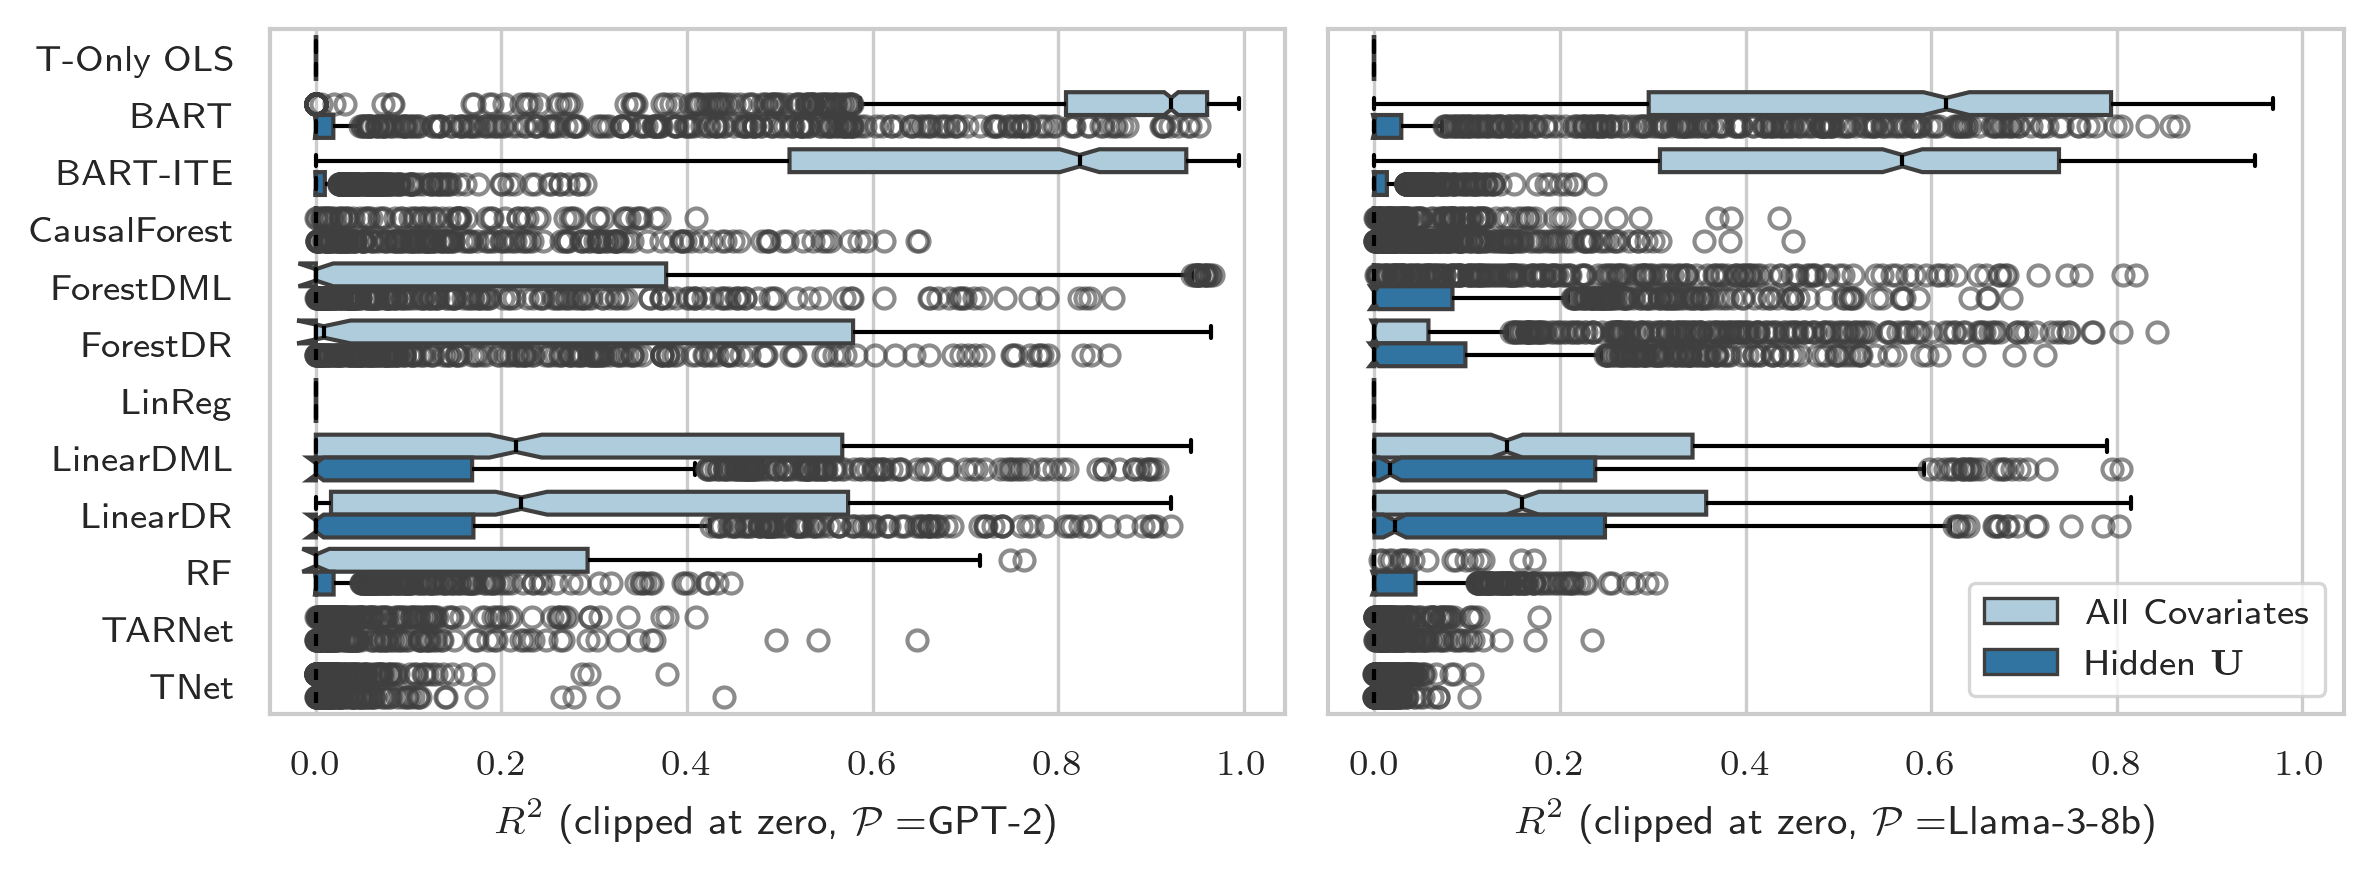

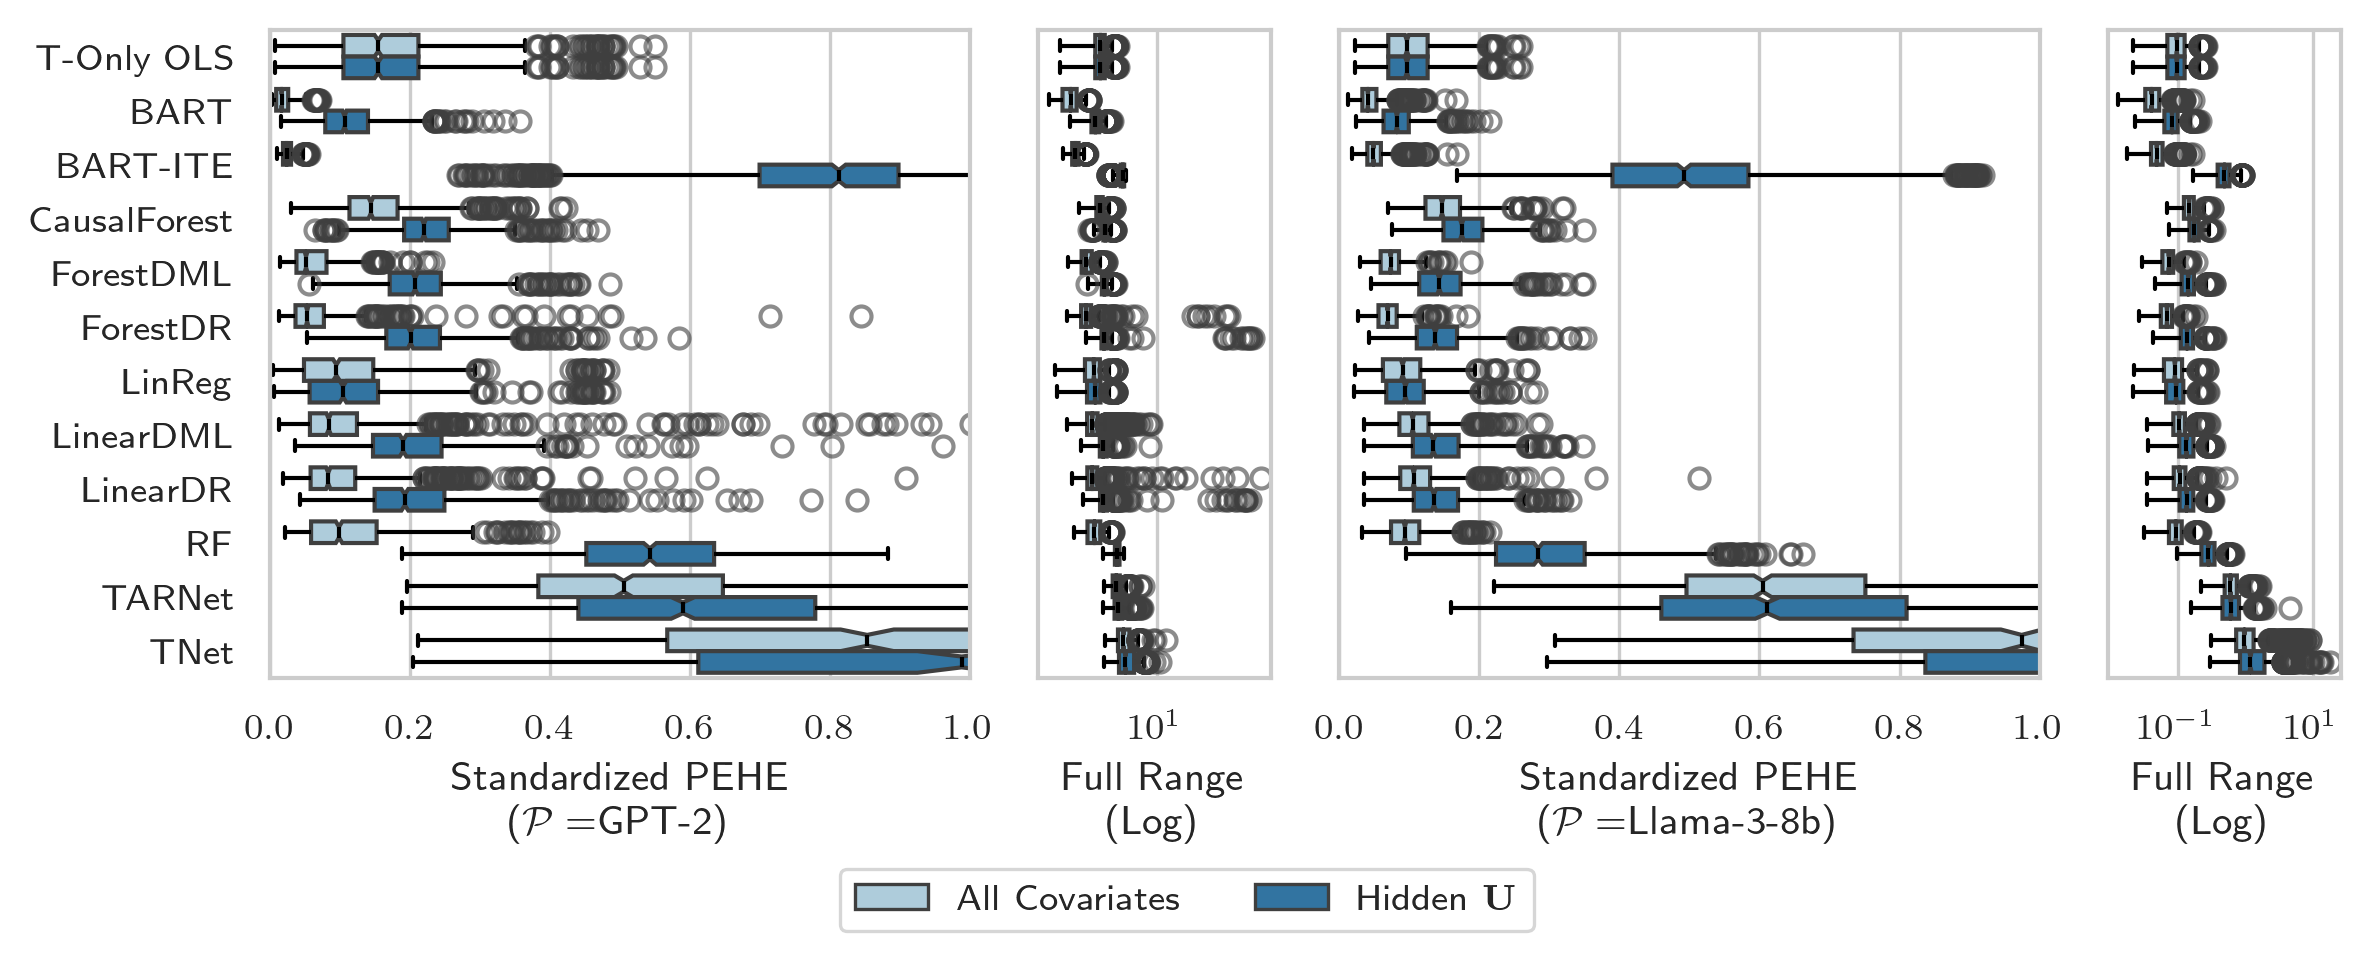

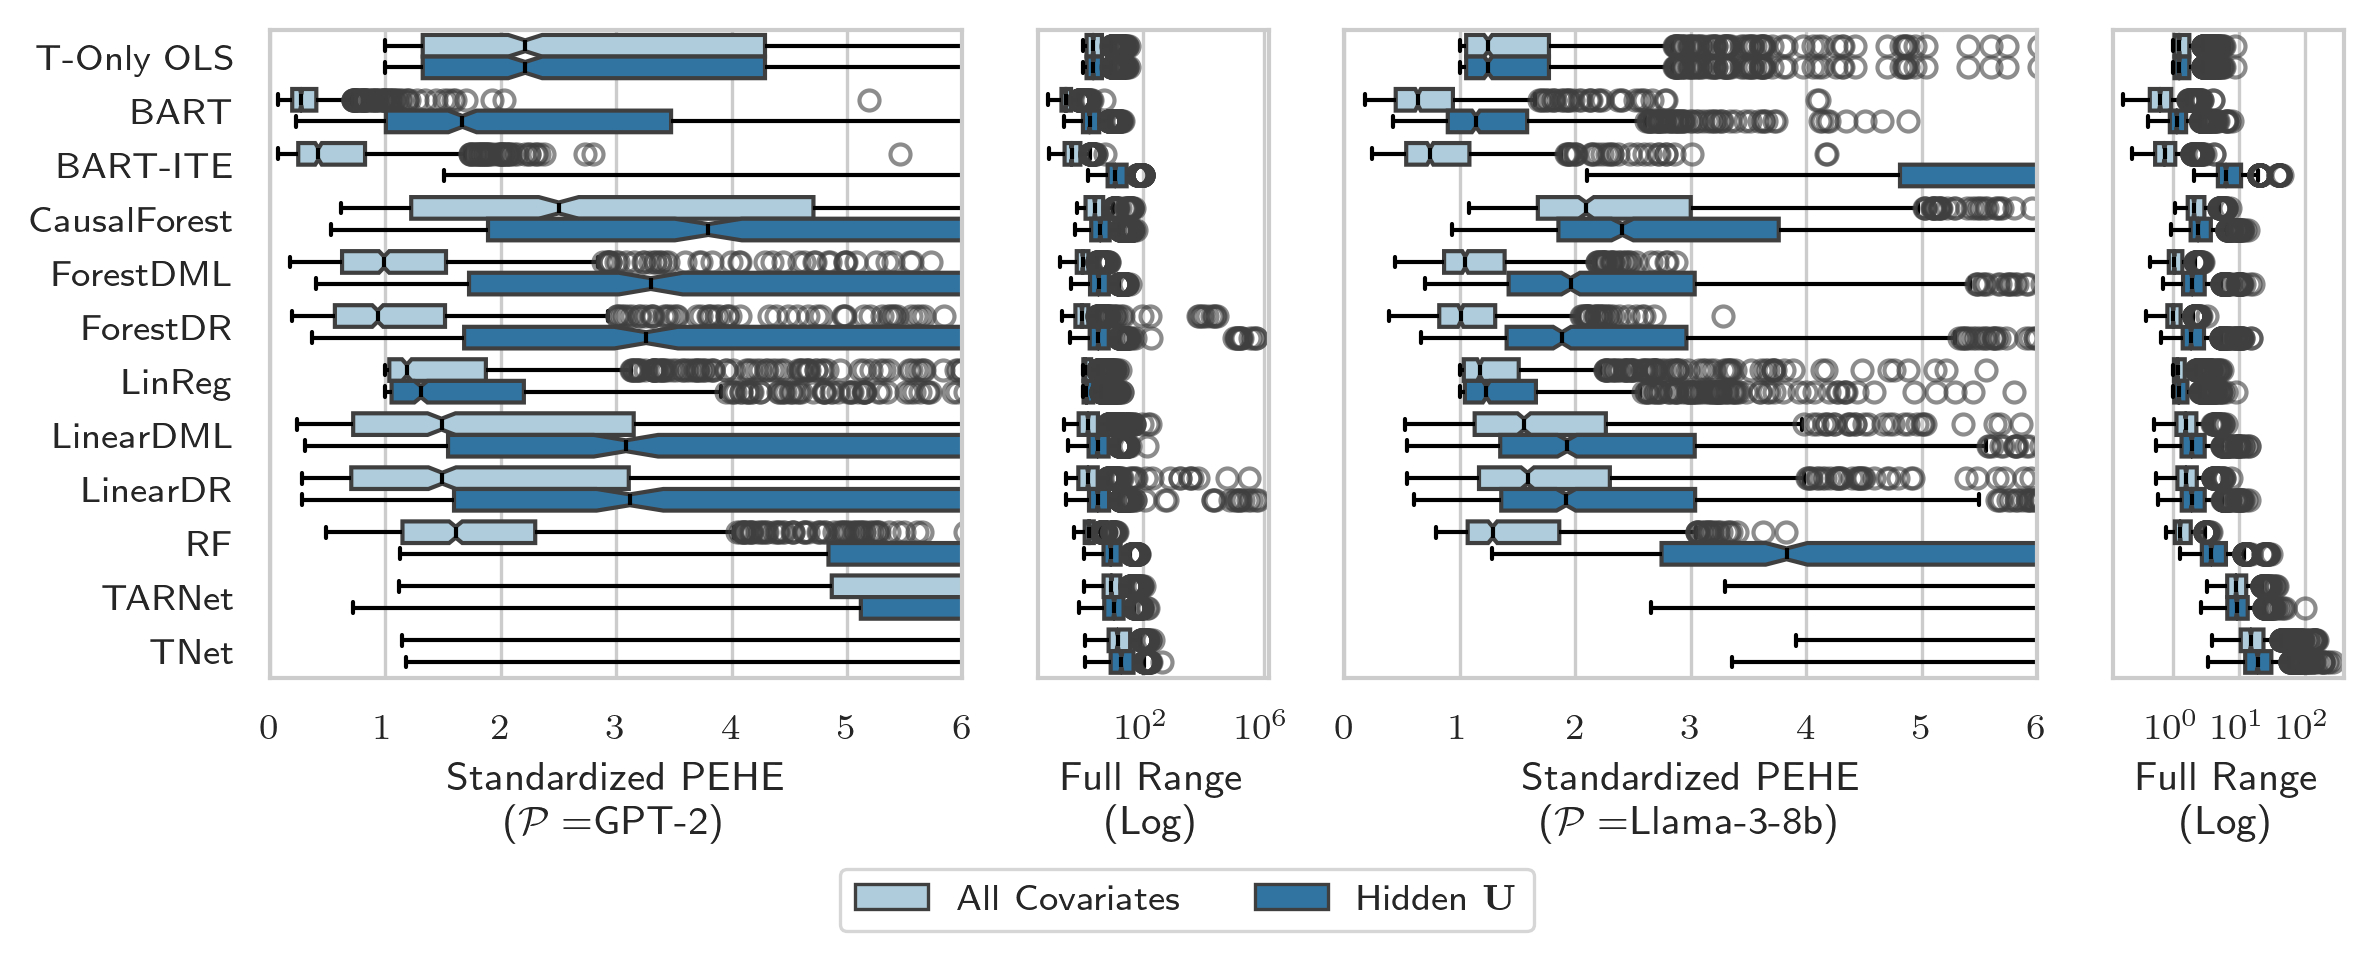

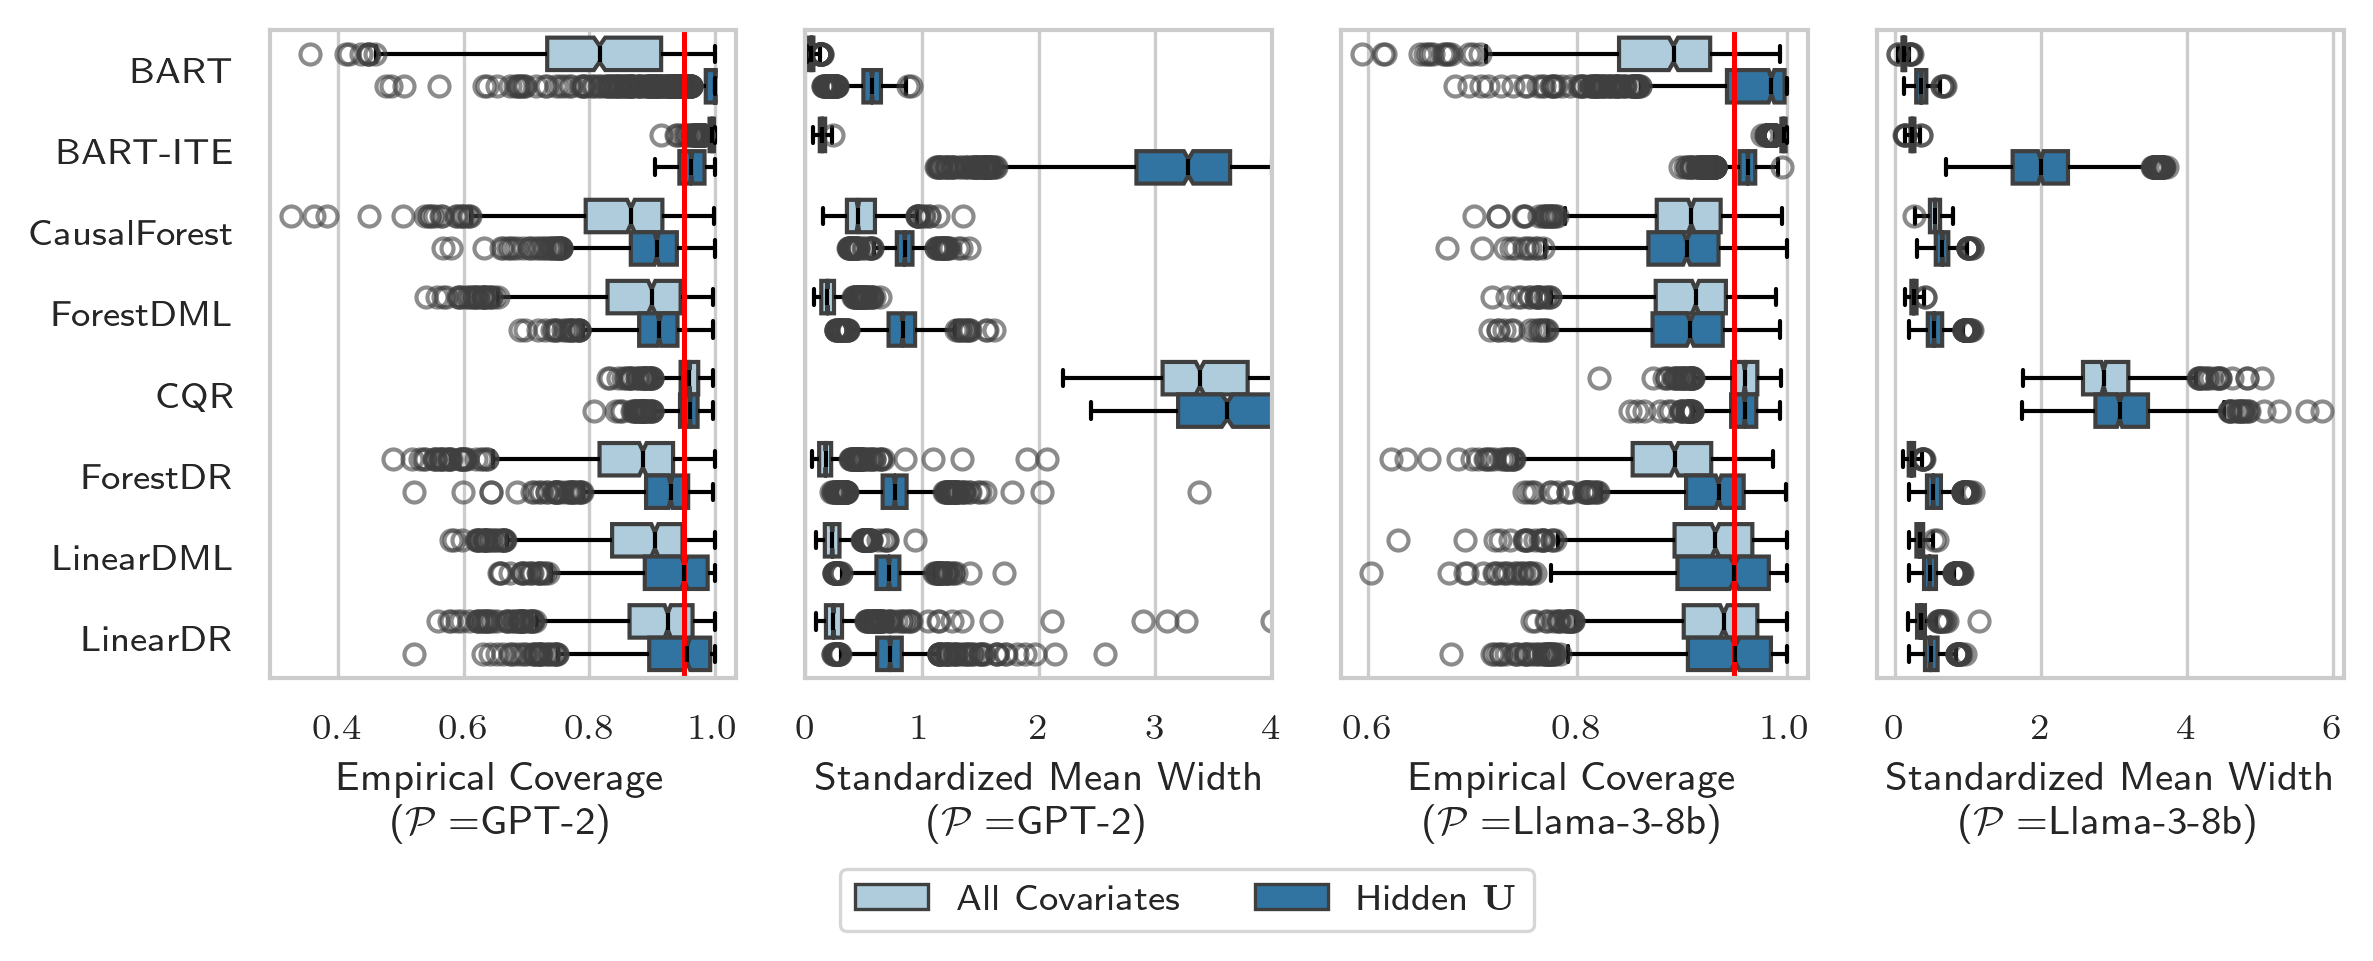

In [6]:
boxplot_settings = {
    'medianprops': {'color': 'black'},
    'whiskerprops': {'color': 'black'},
    'capprops': {'color': 'black'},
    'flierprops': {'alpha': 0.6},
    'palette': 'Paired',
    'meanprops': {'markerfacecolor': 'red', 'markeredgecolor': 'black', 'markersize': 5},
    'notch': True
}
sns.set(rc={'text.usetex' : True}, font_scale=1, context='paper')
sns.set_style('whitegrid')
showmeans = False
method_order = ['T-Only OLS', 'BART', 'BART-ITE', 'CausalForest', 'ForestDML', 'ForestDR', 'LinReg', 'LinearDML', 'LinearDR', 'RF', 'TARNet', 'TNet']
fig, axes = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(8, 3), dpi=300, sharex=True)
axes = axes.ravel()
sns.boxplot(
    data=cate_performance_df[cate_performance_df['model_name'] == 'gpt2'],
    y='method_name',
    x='R2',
    hue='setting',
    showmeans=showmeans,
    ax=axes[0],
    order=method_order,
    **boxplot_settings
)
axes[0].set_ylabel('')
axes[0].set_xlabel(r'$R^2$ (clipped at zero, $\mathcal{P}=$GPT-2)')
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend().remove()
sns.boxplot(
    data=cate_performance_df[cate_performance_df['model_name'] == 'llama-3-8b'], 
    y='method_name', 
    x='R2', 
    hue='setting',
    showmeans=showmeans,
    ax=axes[1],
    order=method_order,
    **boxplot_settings
)
axes[1].legend(title=None)
axes[1].set_xlabel(r'$R^2$ (clipped at zero, $\mathcal{P}=$Llama-3-8b)')

axes[0].xaxis.grid(True)
axes[1].xaxis.grid(True)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows=1, ncols=4, sharey=True, width_ratios=(3, 1, 3, 1), figsize=(8, 3), dpi=300, sharex=False)
axes = axes.ravel()
sns.boxplot(
    data=cate_performance_df[cate_performance_df['model_name'] == 'gpt2'],
    y='method_name',
    x='sd_PEHE',
    hue='setting',
    showmeans=showmeans,
    ax=axes[0],
    order=method_order,
    **boxplot_settings
)
axes[0].set_xlim(0, 1)
axes[0].set_ylabel('')
axes[0].set_xlabel('Standardized PEHE\n' + r'($\mathcal{P}=$GPT-2)')
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend().remove()
sns.boxplot(
    data=cate_performance_df[cate_performance_df['model_name'] == 'gpt2'],
    y='method_name',
    x='sd_PEHE',
    hue='setting',
    showmeans=showmeans,
    ax=axes[1],
    order=method_order,
    **boxplot_settings
)
axes[1].set_ylabel('')
axes[1].set_xlabel('Full Range\n(Log)')
axes[1].set_xscale('log')
axes[1].legend().remove()
sns.boxplot(
    data=cate_performance_df[cate_performance_df['model_name'] == 'llama-3-8b'], 
    y='method_name', 
    x='sd_PEHE', 
    hue='setting',
    showmeans=showmeans,
    ax=axes[2],
    order=method_order,
    **boxplot_settings
)
axes[2].set_xlim(0, 1)
axes[2].legend().remove()
axes[2].set_xlabel('Standardized PEHE\n' + r'($\mathcal{P}=$Llama-3-8b)')
sns.boxplot(
    data=cate_performance_df[cate_performance_df['model_name'] == 'llama-3-8b'], 
    y='method_name', 
    x='sd_PEHE', 
    hue='setting',
    showmeans=showmeans,
    ax=axes[3],
    order=method_order,
    **boxplot_settings
)
axes[3].legend().remove()
axes[3].set_xlabel('Full Range\n(Log)')
axes[3].set_xscale('log')

axes[0].xaxis.grid(True)
axes[1].xaxis.grid(True)
axes[2].xaxis.grid(True)
axes[3].xaxis.grid(True)
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.07), ncol=2, fancybox=True, shadow=False)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows=1, ncols=4, sharey=True, width_ratios=(3, 1, 3, 1), figsize=(8, 3), dpi=300, sharex=False)
axes = axes.ravel()
sns.boxplot(
    data=cate_performance_df[cate_performance_df['model_name'] == 'gpt2'],
    y='method_name',
    x='sd_ite_PEHE',
    hue='setting',
    showmeans=showmeans,
    ax=axes[0],
    order=method_order,
    **boxplot_settings
)
axes[0].set_xlim(0, 6)
axes[0].set_ylabel('')
axes[0].set_xlabel('Standardized PEHE\n' + r'($\mathcal{P}=$GPT-2)')
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend().remove()
sns.boxplot(
    data=cate_performance_df[cate_performance_df['model_name'] == 'gpt2'],
    y='method_name',
    x='sd_ite_PEHE',
    hue='setting',
    showmeans=showmeans,
    ax=axes[1],
    order=method_order,
    **boxplot_settings
)
axes[1].set_ylabel('')
axes[1].set_xlabel('Full Range\n(Log)')
axes[1].set_xscale('log')
axes[1].legend().remove()
sns.boxplot(
    data=cate_performance_df[cate_performance_df['model_name'] == 'llama-3-8b'], 
    y='method_name', 
    x='sd_ite_PEHE', 
    hue='setting',
    showmeans=showmeans,
    ax=axes[2],
    order=method_order,
    **boxplot_settings
)
axes[2].set_xlim(0, 6)
axes[2].legend().remove()
axes[2].set_xlabel('Standardized PEHE\n' + r'($\mathcal{P}=$Llama-3-8b)')
sns.boxplot(
    data=cate_performance_df[cate_performance_df['model_name'] == 'llama-3-8b'], 
    y='method_name', 
    x='sd_ite_PEHE', 
    hue='setting',
    showmeans=showmeans,
    ax=axes[3],
    order=method_order,
    **boxplot_settings
)
axes[3].legend().remove()
axes[3].set_xlabel('Full Range\n(Log)')
axes[3].set_xscale('log')

axes[0].xaxis.grid(True)
axes[1].xaxis.grid(True)
axes[2].xaxis.grid(True)
axes[3].xaxis.grid(True)
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.07), ncol=2, fancybox=True, shadow=False)
plt.tight_layout()
plt.show()

# intervals
method_order = ['BART', 'BART-ITE', 'CausalForest', 'ForestDML', 'CQR', 'ForestDR', 'LinearDML', 'LinearDR']
fig, axes = plt.subplots(nrows=1, ncols=4, sharey=True, figsize=(8, 3), dpi=300, sharex=False)
axes = axes.ravel()
sns.boxplot(
    data=cate_performance_df[cate_performance_df['model_name'] == 'gpt2'].dropna(subset=['coverage_cate']),
    y='method_name',
    x='coverage_cate',
    hue='setting',
    ax=axes[0],
    order=method_order,
    **boxplot_settings
)
axes[0].axvline(x=0.95, color='red')
axes[0].set_ylabel('')
axes[0].set_xlabel('Empirical Coverage\n' + r'($\mathcal{P}=$GPT-2)')
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend().remove()
sns.boxplot(
    data=cate_performance_df[cate_performance_df['model_name'] == 'gpt2'].dropna(subset=['coverage_cate']),
    y='method_name',
    x='sd_width_cate',
    hue='setting',
    ax=axes[1],
    order=method_order,
    **boxplot_settings
)
axes[1].legend().remove()
axes[1].set_xlim(0, 4)
axes[1].set_xlabel('Standardized Mean Width\n' + r'($\mathcal{P}=$GPT-2)')
sns.boxplot(
    data=cate_performance_df[cate_performance_df['model_name'] == 'llama-3-8b'].dropna(subset=['coverage_cate']), 
    y='method_name', 
    x='coverage_cate', 
    hue='setting',
    ax=axes[2],
    order=method_order,
    **boxplot_settings
)
axes[2].axvline(x=0.95, color='red')
axes[2].legend().remove()
axes[2].set_xlabel('Empirical Coverage\n' + r'($\mathcal{P}=$Llama-3-8b)')

sns.boxplot(
    data=cate_performance_df[cate_performance_df['model_name'] == 'llama-3-8b'].dropna(subset=['coverage_cate']),
    y='method_name',
    x='sd_width_cate',
    hue='setting',
    ax=axes[3],
    order=method_order,
    **boxplot_settings
)
handles, labels = axes[3].get_legend_handles_labels()
axes[3].legend().remove()
axes[3].set_xlabel('Standardized Mean Width\n' + r'($\mathcal{P}=$Llama-3-8b)')

axes[0].xaxis.grid(True)
axes[1].xaxis.grid(True)
axes[2].xaxis.grid(True)
axes[3].xaxis.grid(True)
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.07), ncol=2, fancybox=True, shadow=False)
plt.tight_layout()
plt.show()

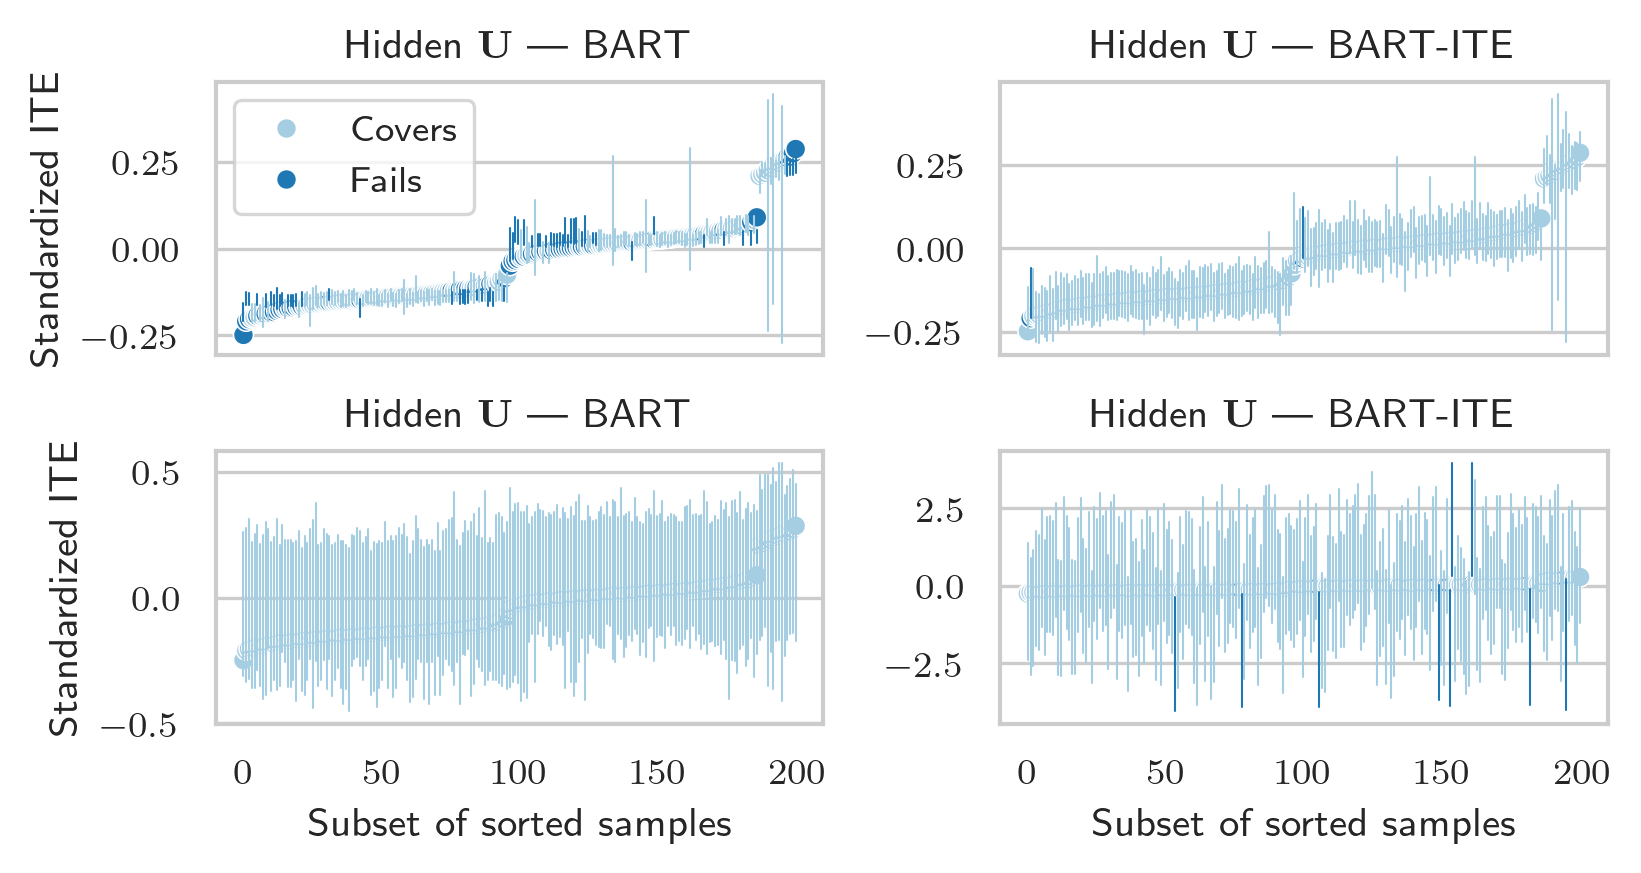

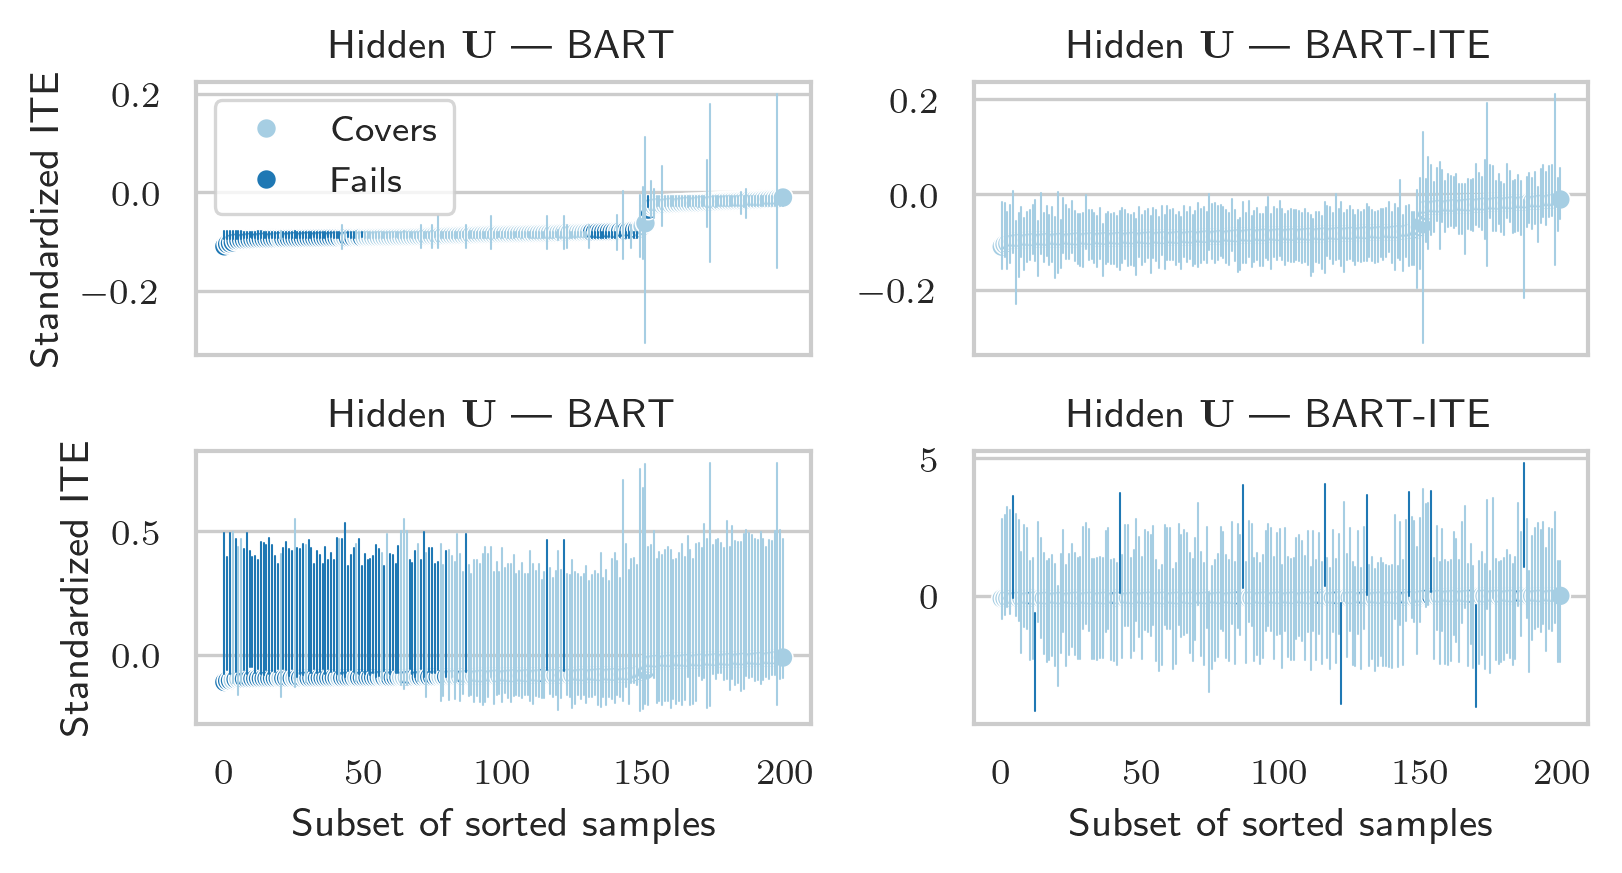

In [7]:
for df_path in ['data/cancer_example/gpt2/gpt2_bcancer_0.csv', 'data/cancer_example/gpt2/gpt2_bcancer_49.csv']:
    interval_example = estimation_df[estimation_df['df_path'] == df_path]
    confounding_setting = interval_example['covariate_names'].apply(len) < 12
    all_covariates_setting = (1 - confounding_setting).astype(bool)

    coverage_dfs = []
    for setting_name, setting in [('All Covariates', all_covariates_setting), (r'Hidden $\mathbf{U}$', confounding_setting)]:
        for method_name in ['BART', 'BART-ITE']:
            sd_y = interval_example[setting]['y'].values[0].std()
            ites = interval_example[setting]['ite'].values[0] / sd_y
            lower = interval_example[setting][f'cate_lower_bounds_{method_name}'].values[0] / sd_y
            upper = interval_example[setting][f'cate_upper_bounds_{method_name}'].values[0] / sd_y
            covers = (ites > lower) * (ites < upper)
            df = pd.DataFrame(dict(ite=ites, lower=lower, upper=upper, covers=covers, method=method_name, setting=setting_name)).sort_values('ite')
            df['full_index'] = list(range(df.shape[0]))
            df['sample'] = df['full_index'] % 5 == 0
            df['index'] = np.nan
            df['index'][df['sample']] = list(range(sum(df['sample'])))
            coverage_dfs.append(df)
    coverage_df = pd.concat(coverage_dfs, axis=0)
    
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(5.5, 3), dpi=300, sharex=True, sharey=False)
    axes = axes.ravel()
        
    colors = sns.color_palette('Paired')
    i = 0
    for setting in ['All Covariates', r'Hidden $\mathbf{U}$']:
        for method in ['BART', 'BART-ITE']:
            query = f"setting=='{setting}' & sample==True & method=='{method}'"
            df = coverage_df.query(query)
            sns.scatterplot(data=df, x='index', y='ite', hue='covers', palette='Paired', ax=axes[i], hue_order=[True, False])
            for _, row in df.iterrows():
                color = colors[0] if row['covers'] else colors[1]
                axes[i].plot(
                    [row['index'], row['index']], [row['lower'], row['upper']], 
                    color=color, 
                    lw=0.5
                )
            axes[i].set_title(f'{setting_name} | {method}')
            i += 1
    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].legend(title='', handles=handles, labels=['Covers', 'Fails'])
    for i in range(4):
        if i != 0:
            axes[i].legend().remove()
        axes[i].set_xlabel('Subset of sorted samples')
        if i % 2 == 0:
            axes[i].set_ylabel('Standardized ITE')
        else:
            axes[i].set_ylabel('')
        axes[i].xaxis.grid(False, which='major')
    plt.tight_layout()
    plt.show()

# 10k

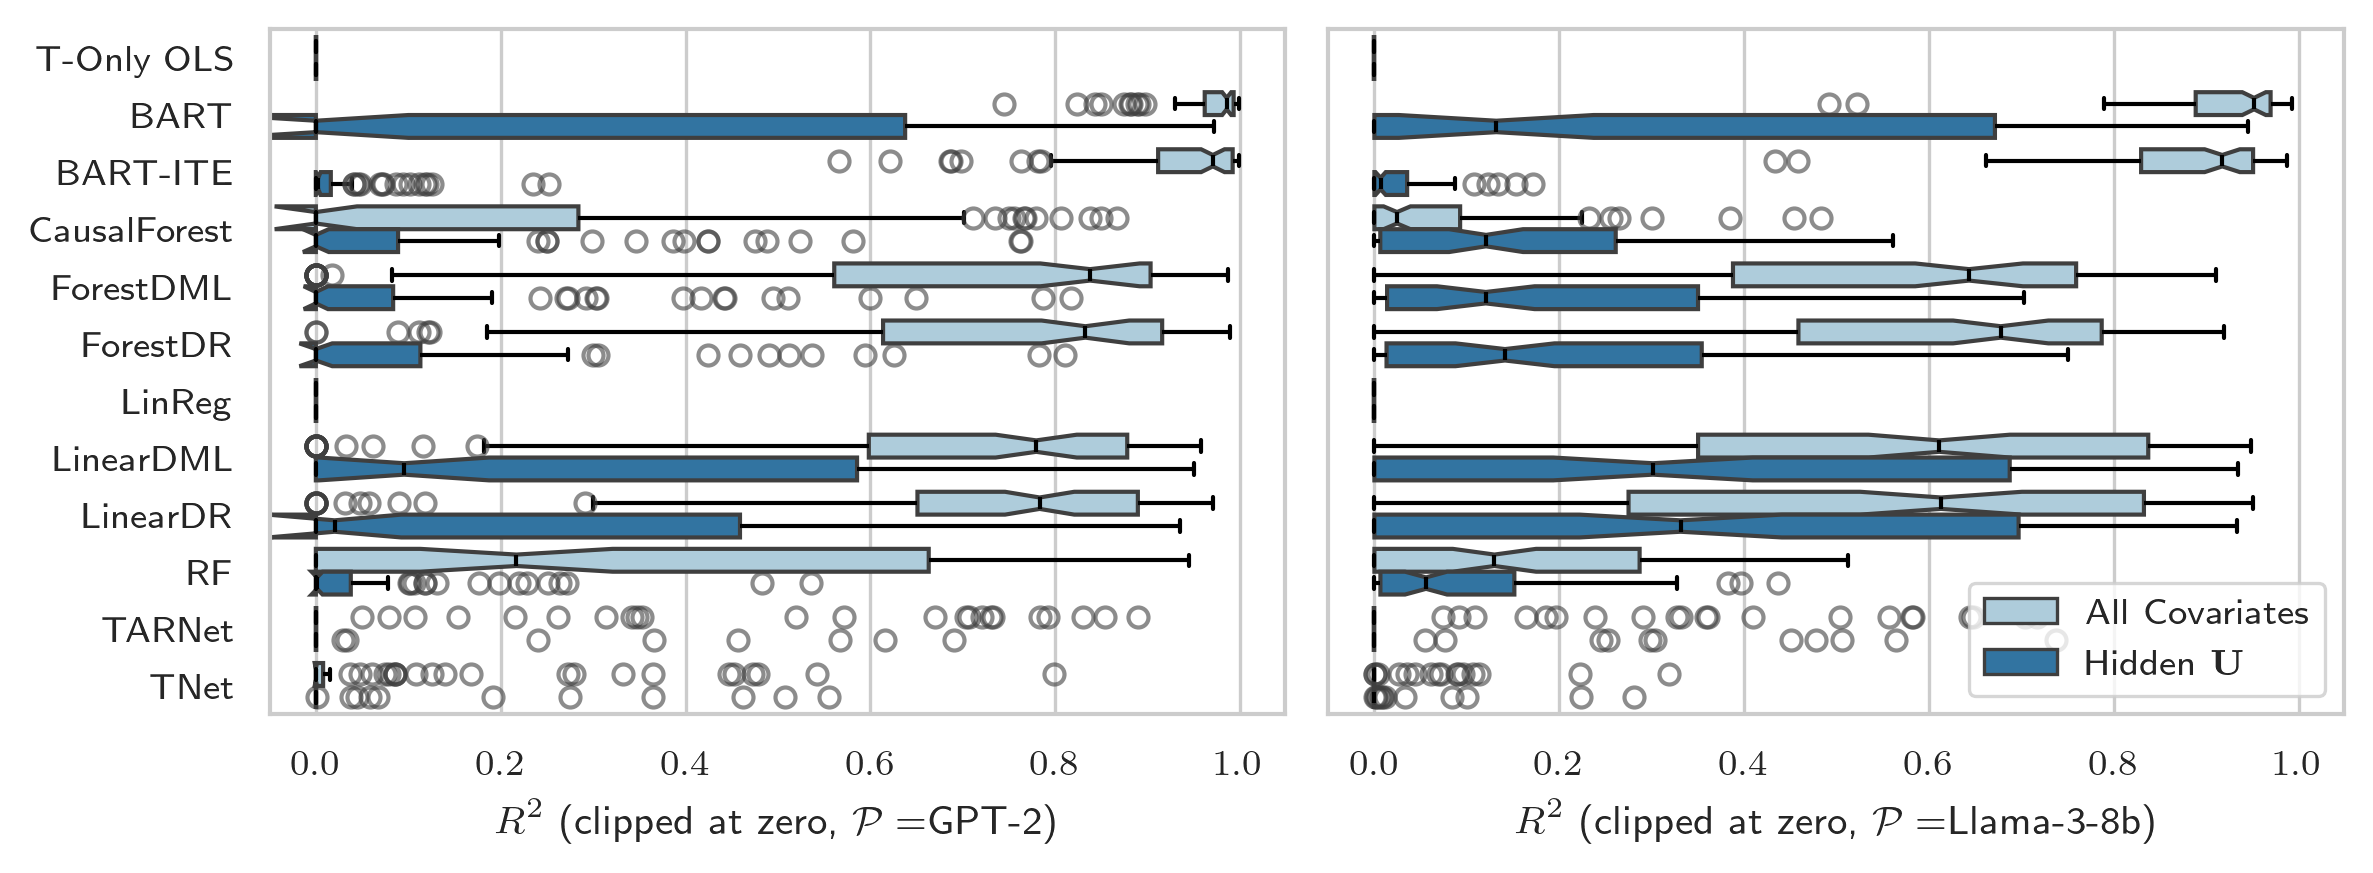

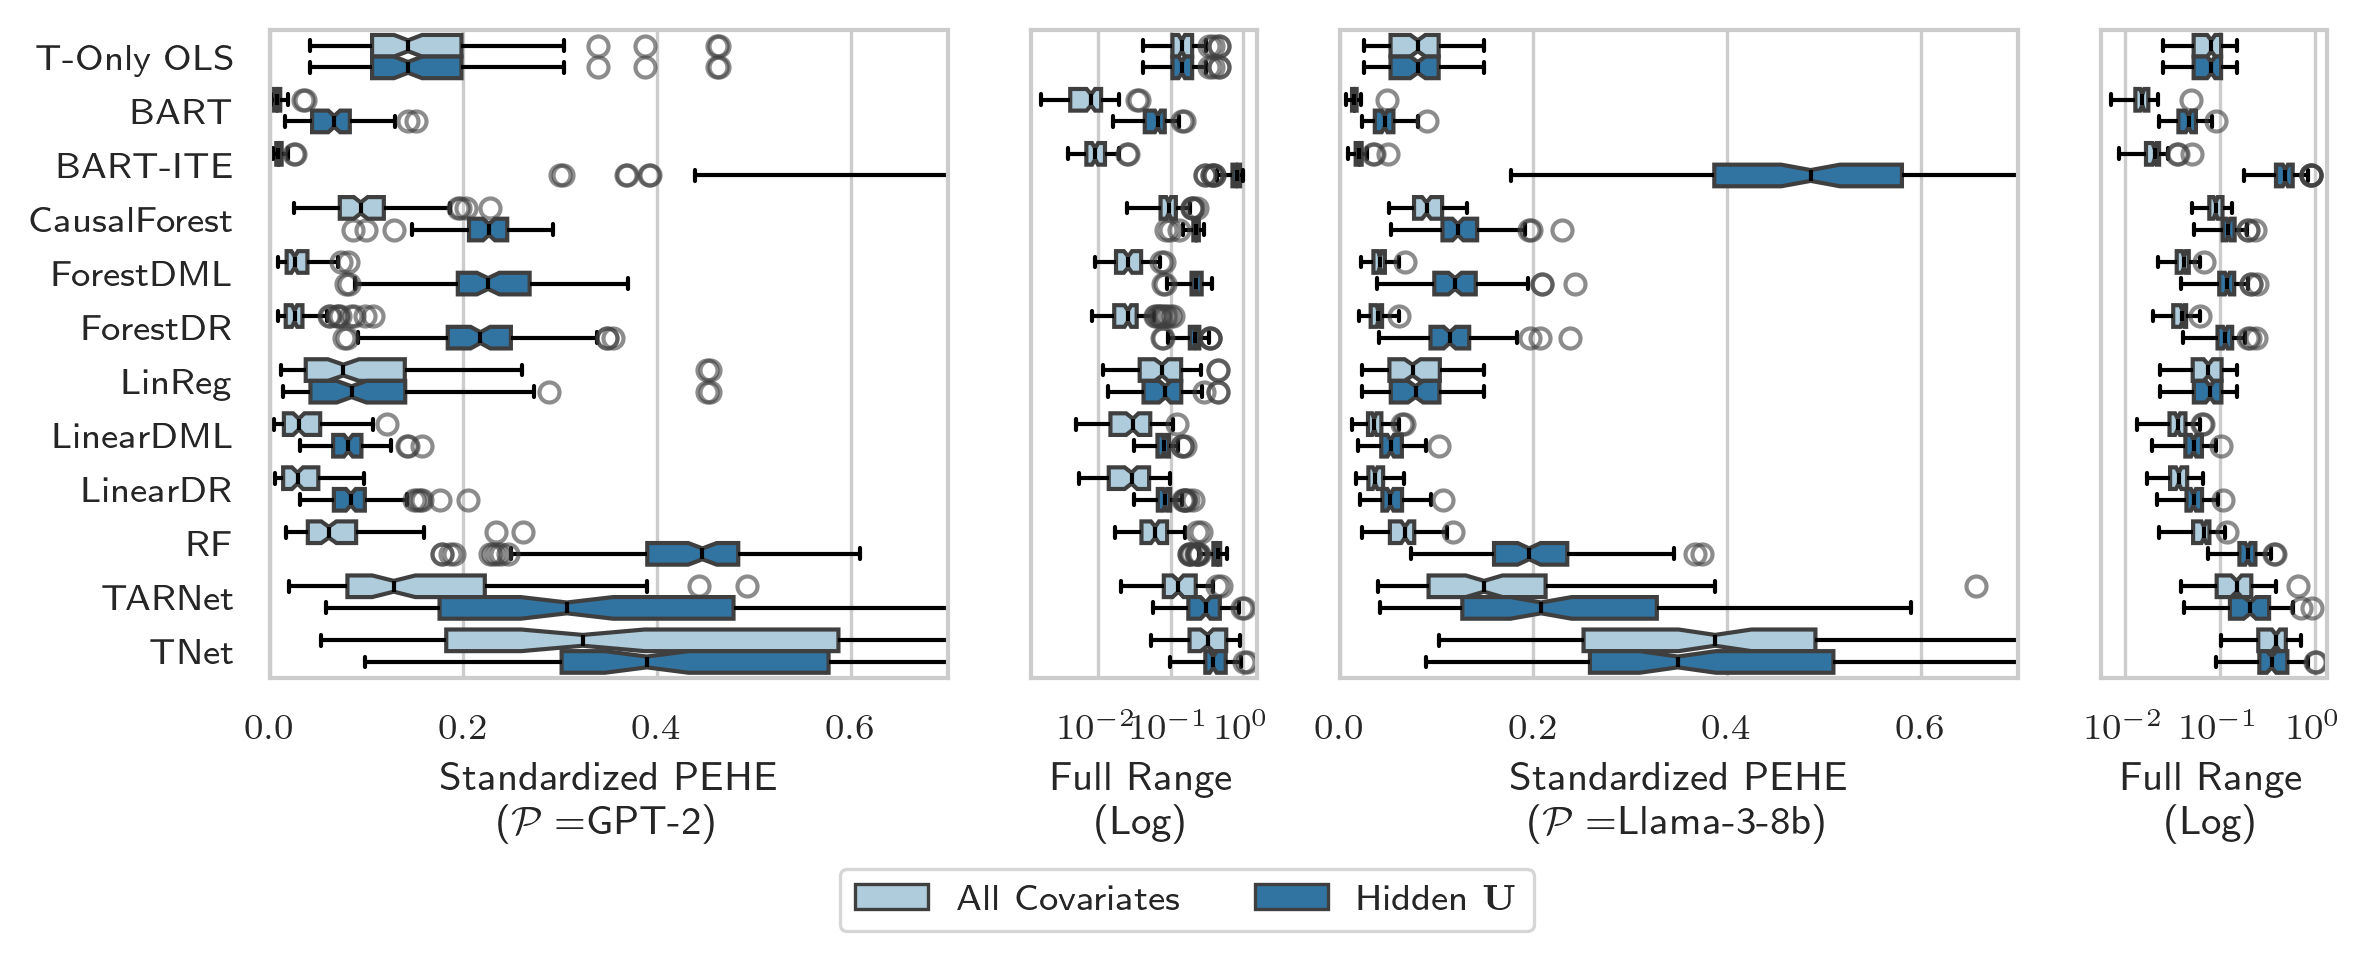

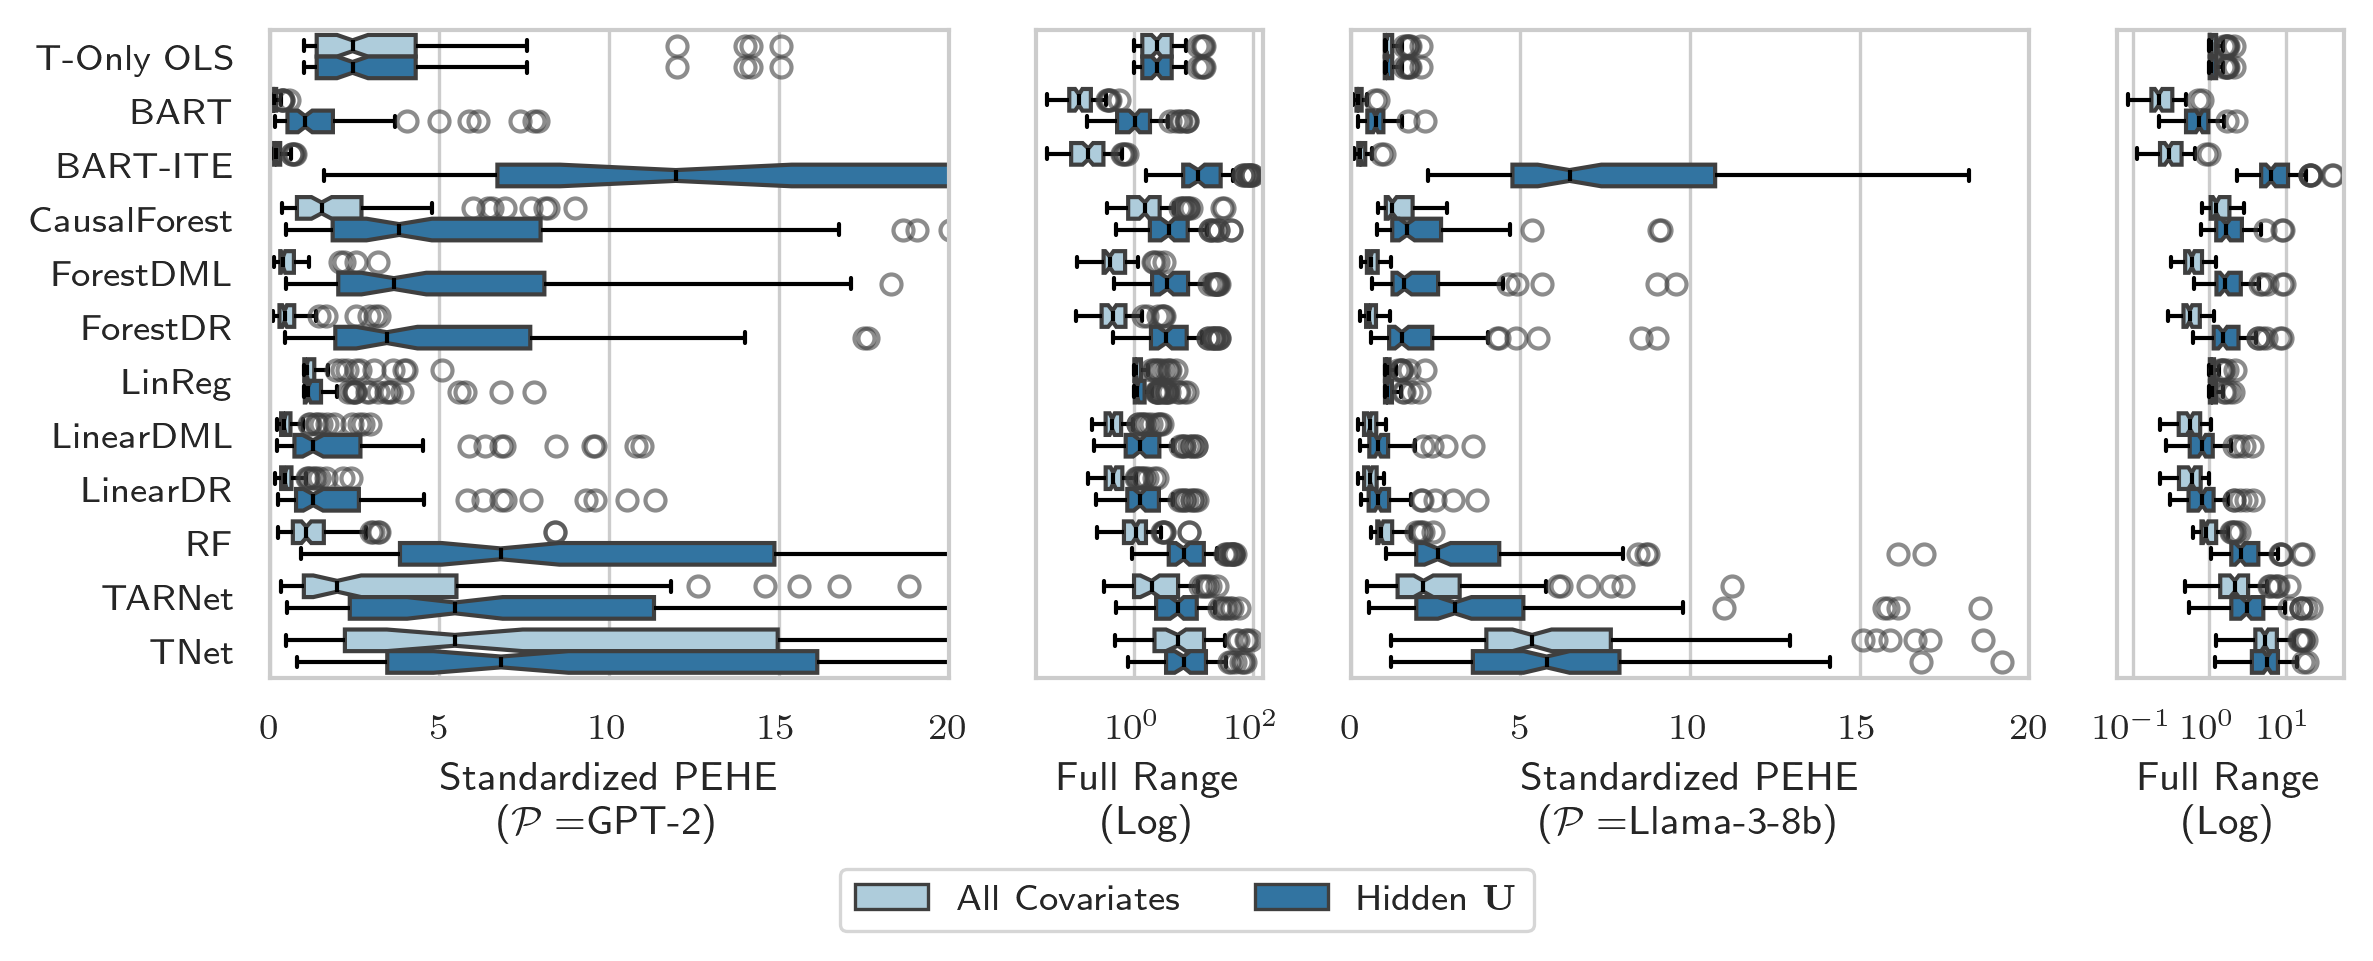

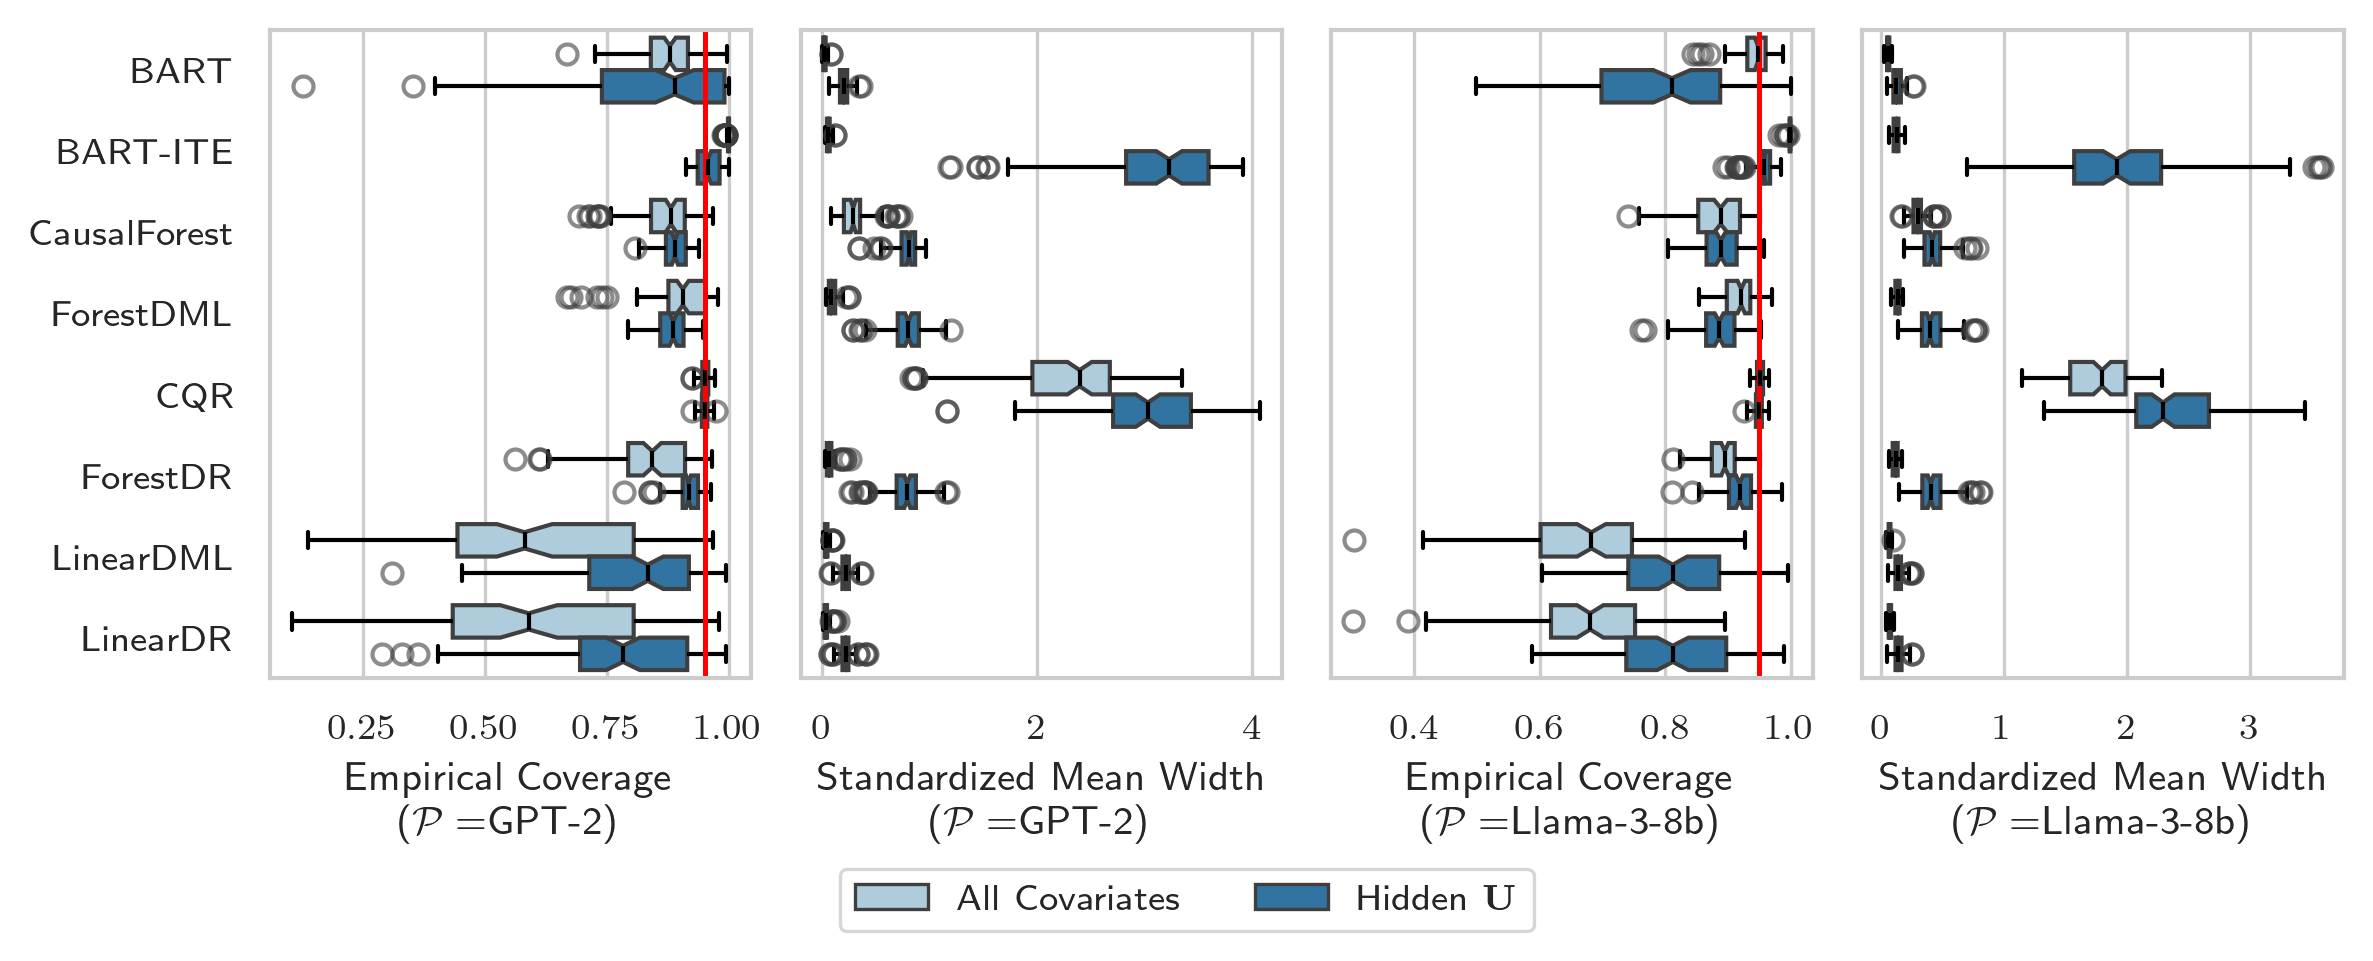

In [8]:
cate_10k_performance_df = format_cate_performance_df(estimation_df=estimation_10k_df)
cate_10k_performance_df['method_name'] = cate_10k_performance_df['method_name'].replace({
    'NaiveLinReg': 'T-Only OLS',
    'CausalForestDML': 'ForestDML',
    'SNet1': 'TARNet',
    'Conformal': 'CQR'
})

boxplot_settings = {
    'medianprops': {'color': 'black'},
    'whiskerprops': {'color': 'black'},
    'capprops': {'color': 'black'},
    'flierprops': {'alpha': 0.6},
    'palette': 'Paired',
    'meanprops': {'markerfacecolor': 'red', 'markeredgecolor': 'black', 'markersize': 5},
    'notch': True
}
showmeans = False
sns.set(rc={'text.usetex' : True}, font_scale=1, context='paper')
sns.set_style('whitegrid')

method_order = ['T-Only OLS', 'BART', 'BART-ITE', 'CausalForest', 'ForestDML', 'ForestDR', 'LinReg', 'LinearDML', 'LinearDR', 'RF', 'TARNet', 'TNet']
fig, axes = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(8, 3), dpi=300, sharex=True)
axes = axes.ravel()
sns.boxplot(
    data=cate_10k_performance_df[cate_10k_performance_df['model_name'] == 'gpt2'],
    y='method_name',
    x='R2',
    hue='setting',
    showmeans=showmeans,
    ax=axes[0],
    order=method_order,
    **boxplot_settings
)
axes[0].set_ylabel('')
axes[0].set_xlabel(r'$R^2$ (clipped at zero, $\mathcal{P}=$GPT-2)')
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend().remove()
sns.boxplot(
    data=cate_10k_performance_df[cate_10k_performance_df['model_name'] == 'llama-3-8b'], 
    y='method_name', 
    x='R2', 
    hue='setting',
    showmeans=showmeans,
    ax=axes[1],
    order=method_order,
    **boxplot_settings
)
axes[1].legend(title=None)
axes[1].set_xlabel(r'$R^2$ (clipped at zero, $\mathcal{P}=$Llama-3-8b)')

axes[0].xaxis.grid(True)
axes[1].xaxis.grid(True)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows=1, ncols=4, sharey=True, width_ratios=(3, 1, 3, 1), figsize=(8, 3), dpi=300, sharex=False)
axes = axes.ravel()
sns.boxplot(
    data=cate_10k_performance_df[cate_10k_performance_df['model_name'] == 'gpt2'],
    y='method_name',
    x='sd_PEHE',
    hue='setting',
    showmeans=showmeans,
    ax=axes[0],
    order=method_order,
    **boxplot_settings
)
axes[0].set_ylabel('')
axes[0].set_xlabel('Standardized PEHE\n' + r'($\mathcal{P}=$GPT-2)')
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend().remove()
sns.boxplot(
    data=cate_10k_performance_df[cate_10k_performance_df['model_name'] == 'gpt2'],
    y='method_name',
    x='sd_PEHE',
    hue='setting',
    showmeans=showmeans,
    ax=axes[1],
    order=method_order,
    **boxplot_settings
)
axes[1].set_ylabel('')
axes[1].set_xlabel('Full Range\n(Log)')
axes[1].set_xscale('log')
axes[1].legend().remove()
sns.boxplot(
    data=cate_10k_performance_df[cate_10k_performance_df['model_name'] == 'llama-3-8b'], 
    y='method_name', 
    x='sd_PEHE', 
    hue='setting',
    showmeans=showmeans,
    ax=axes[2],
    order=method_order,
    **boxplot_settings
)
axes[2].legend().remove()
axes[2].set_xlabel('Standardized PEHE\n' + r'($\mathcal{P}=$Llama-3-8b)')
sns.boxplot(
    data=cate_10k_performance_df[cate_10k_performance_df['model_name'] == 'llama-3-8b'], 
    y='method_name', 
    x='sd_PEHE', 
    hue='setting',
    showmeans=showmeans,
    ax=axes[3],
    order=method_order,
    **boxplot_settings
)
axes[3].legend().remove()
axes[3].set_xlabel('Full Range\n(Log)')
axes[3].set_xscale('log')

axes[0].set_xlim(0, 0.7)
axes[2].set_xlim(0, 0.7)

axes[0].xaxis.grid(True)
axes[1].xaxis.grid(True)
axes[2].xaxis.grid(True)
axes[3].xaxis.grid(True)
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.07), ncol=2, fancybox=True, shadow=False)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows=1, ncols=4, sharey=True, width_ratios=(3, 1, 3, 1), figsize=(8, 3), dpi=300, sharex=False)
axes = axes.ravel()
sns.boxplot(
    data=cate_10k_performance_df[cate_10k_performance_df['model_name'] == 'gpt2'],
    y='method_name',
    x='sd_ite_PEHE',
    hue='setting',
    showmeans=showmeans,
    ax=axes[0],
    order=method_order,
    **boxplot_settings
)
axes[0].set_ylabel('')
axes[0].set_xlabel('Standardized PEHE\n' + r'($\mathcal{P}=$GPT-2)')
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend().remove()
sns.boxplot(
    data=cate_10k_performance_df[cate_10k_performance_df['model_name'] == 'gpt2'],
    y='method_name',
    x='sd_ite_PEHE',
    hue='setting',
    showmeans=showmeans,
    ax=axes[1],
    order=method_order,
    **boxplot_settings
)
axes[1].set_ylabel('')
axes[1].set_xlabel('Full Range\n(Log)')
axes[1].set_xscale('log')
axes[1].legend().remove()
sns.boxplot(
    data=cate_10k_performance_df[cate_10k_performance_df['model_name'] == 'llama-3-8b'], 
    y='method_name', 
    x='sd_ite_PEHE', 
    hue='setting',
    showmeans=showmeans,
    ax=axes[2],
    order=method_order,
    **boxplot_settings
)
axes[2].legend().remove()
axes[2].set_xlabel('Standardized PEHE\n' + r'($\mathcal{P}=$Llama-3-8b)')
sns.boxplot(
    data=cate_10k_performance_df[cate_10k_performance_df['model_name'] == 'llama-3-8b'], 
    y='method_name', 
    x='sd_ite_PEHE', 
    hue='setting',
    showmeans=showmeans,
    ax=axes[3],
    order=method_order,
    **boxplot_settings
)
axes[3].legend().remove()
axes[3].set_xlabel('Full Range\n(Log)')
axes[3].set_xscale('log')

axes[0].set_xlim(0, 20)
axes[2].set_xlim(0, 20)

axes[0].xaxis.grid(True)
axes[1].xaxis.grid(True)
axes[2].xaxis.grid(True)
axes[3].xaxis.grid(True)
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.07), ncol=2, fancybox=True, shadow=False)
plt.tight_layout()
plt.show()

# intervals
method_order = ['BART', 'BART-ITE', 'CausalForest', 'ForestDML', 'CQR', 'ForestDR', 'LinearDML', 'LinearDR']
fig, axes = plt.subplots(nrows=1, ncols=4, sharey=True, figsize=(8, 3), dpi=300, sharex=False)
axes = axes.ravel()
sns.boxplot(
    data=cate_10k_performance_df[cate_10k_performance_df['model_name'] == 'gpt2'].dropna(subset=['coverage_cate']),
    y='method_name',
    x='coverage_cate',
    hue='setting',
    ax=axes[0],
    order=method_order,
    **boxplot_settings
)
axes[0].axvline(x=0.95, color='red')
axes[0].set_ylabel('')
axes[0].set_xlabel('Empirical Coverage\n' + r'($\mathcal{P}=$GPT-2)')
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend().remove()
sns.boxplot(
    data=cate_10k_performance_df[cate_10k_performance_df['model_name'] == 'gpt2'].dropna(subset=['coverage_cate']),
    y='method_name',
    x='sd_width_cate',
    hue='setting',
    ax=axes[1],
    order=method_order,
    **boxplot_settings
)
axes[1].legend().remove()
axes[1].set_xlabel('Standardized Mean Width\n' + r'($\mathcal{P}=$GPT-2)')
sns.boxplot(
    data=cate_10k_performance_df[cate_10k_performance_df['model_name'] == 'llama-3-8b'].dropna(subset=['coverage_cate']), 
    y='method_name', 
    x='coverage_cate', 
    hue='setting',
    ax=axes[2],
    order=method_order,
    **boxplot_settings
)
axes[2].axvline(x=0.95, color='red')
axes[2].legend().remove()
axes[2].set_xlabel('Empirical Coverage\n' + r'($\mathcal{P}=$Llama-3-8b)')

sns.boxplot(
    data=cate_10k_performance_df[cate_10k_performance_df['model_name'] == 'llama-3-8b'].dropna(subset=['coverage_cate']),
    y='method_name',
    x='sd_width_cate',
    hue='setting',
    ax=axes[3],
    order=method_order,
    **boxplot_settings
)
handles, labels = axes[3].get_legend_handles_labels()
axes[3].legend().remove()
axes[3].set_xlabel('Standardized Mean Width\n' + r'($\mathcal{P}=$Llama-3-8b)')

axes[0].xaxis.grid(True)
axes[1].xaxis.grid(True)
axes[2].xaxis.grid(True)
axes[3].xaxis.grid(True)
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.07), ncol=2, fancybox=True, shadow=False)
plt.tight_layout()
plt.show()

setting      All Covariates                                 \
                    Mean R2                                  
model_name             gpt2           llama-3-8b             
dataset_size          1000      10000      1000      10000   
method_name                                                  
T-Only OLS               ≤0        ≤0         ≤0        ≤0   
BART               0.716215  0.969057   0.522084   0.92135   
BART-ITE           0.710178  0.934383    0.51829  0.882336   
CausalForest             ≤0        ≤0         ≤0        ≤0   
ForestDML                ≤0   0.66048         ≤0  0.555053   
ForestDR                 ≤0  0.722031         ≤0   0.59677   
LinReg                   ≤0        ≤0         ≤0        ≤0   
LinearDML          0.238145   0.53088   0.149063  0.540352   
LinearDR           0.232868  0.590034    0.15615  0.529311   
RF                       ≤0  0.032707         ≤0  0.103837   
TARNet                   ≤0        ≤0         ≤0        ≤0   
TNet                     ≤0        ≤0         ≤0        ≤0   

setting      Hidden $\mathbf{U}$                                 
                         Mean R2                                 
model_name                  gpt2           llama-3-8b            
dataset_size               1000      10000      1000      10000  
method_name                                                      
T-Only OLS                    ≤0        ≤0         ≤0        ≤0  
BART                          ≤0        ≤0         ≤0        ≤0  
BART-ITE                0.005354  0.018543   0.001146  0.016909  
CausalForest                  ≤0  0.031344         ≤0  0.139907  
ForestDML                     ≤0  0.060788         ≤0  0.185019  
ForestDR                      ≤0  0.050271         ≤0  0.193114  
LinReg                        ≤0        ≤0         ≤0        ≤0  
LinearDML                     ≤0        ≤0         ≤0  0.148345  
LinearDR                      ≤0        ≤0         ≤0  0.173373  
RF                      0.002361  0.037292   0.006039  0.094029  
TARNet                        ≤0        ≤0         ≤0        ≤0  
TNet                          ≤0        ≤0         ≤0        ≤0

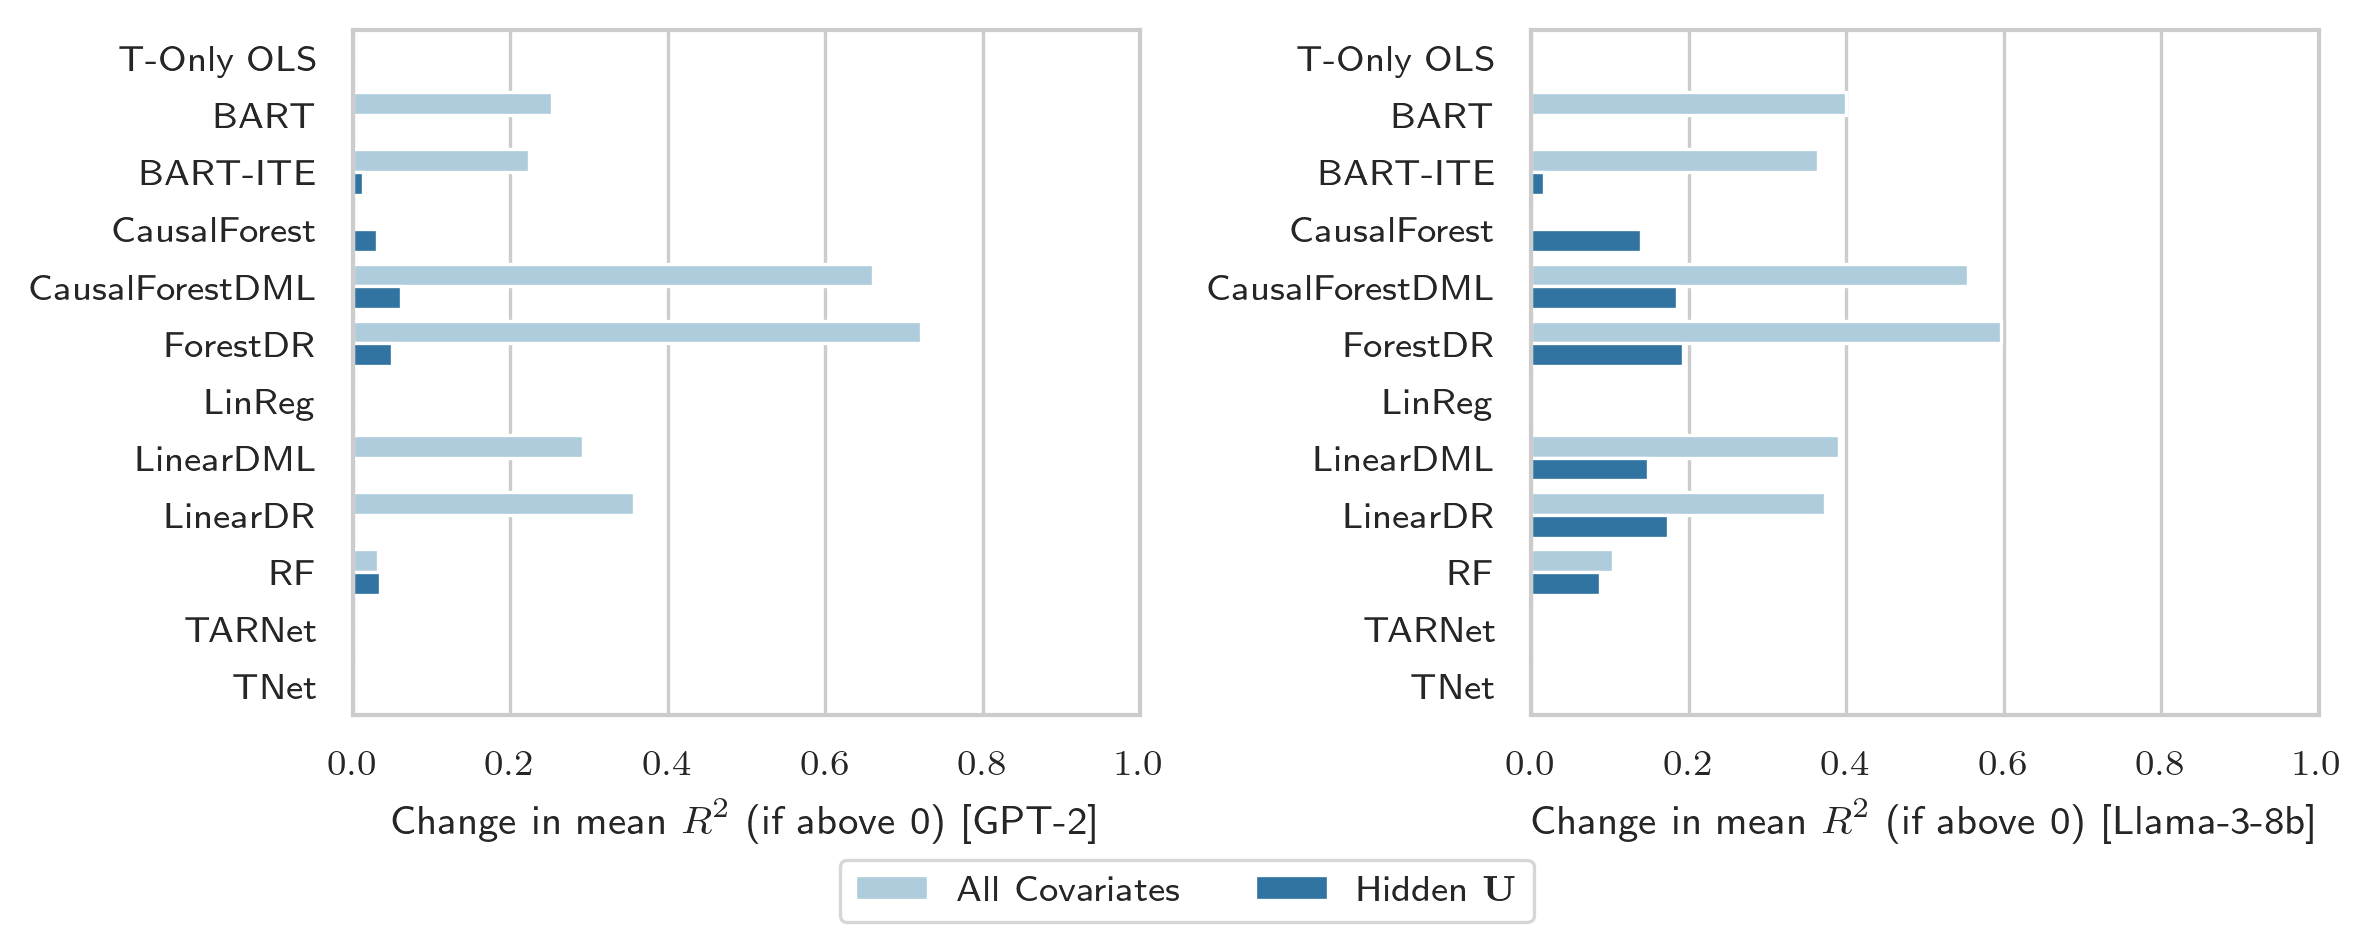

In [9]:
method_order = ['T-Only OLS', 'BART', 'BART-ITE', 'CausalForest', 'ForestDML', 'ForestDR', 'LinReg', 'LinearDML', 'LinearDR', 'RF', 'TARNet', 'TNet']
grouped_1k_cate_performance_df = cate_performance_df.groupby(['method_name', 'setting', 'model_name'])['R2_cate'].mean().reset_index()
grouped_10k_cate_performance_df = cate_10k_performance_df.groupby(['method_name', 'setting', 'model_name'])['R2_cate'].mean().reset_index()
grouped_1k_cate_performance_df['dataset_size'] = 1000
grouped_10k_cate_performance_df['dataset_size'] = 10000
grouped_cate_performance_df = pd.concat(
    (grouped_1k_cate_performance_df, grouped_10k_cate_performance_df),
    axis=0
).rename(columns={'R2_cate': 'Mean R2'})
unstacked_cate_performance_df = grouped_cate_performance_df.copy(deep=True).reset_index()

grouped_cate_performance_df['Mean R2'][grouped_cate_performance_df['Mean R2'] <= 0] = '≤0'
grouped_cate_performance_df = grouped_cate_performance_df.pivot(
    index=['method_name'], 
    columns=['setting', 'model_name', 'dataset_size']
)
grouped_cate_performance_df.columns = grouped_cate_performance_df.columns.swaplevel(0, 1)
grouped_cate_performance_df = grouped_cate_performance_df.sort_index(axis=1, level=0)
display(grouped_cate_performance_df.loc[method_order])

method_order = ['T-Only OLS', 'BART', 'BART-ITE', 'CausalForest', 'CausalForestDML', 'ForestDR', 'LinReg', 'LinearDML', 'LinearDR', 'RF', 'TARNet', 'TNet']
long_df = pd.concat(
    (grouped_1k_cate_performance_df, grouped_10k_cate_performance_df),
    axis=0
).rename(columns={'R2_cate': 'mean_R2'}).sort_values(by='dataset_size', ascending=True)
long_df['mean_R2'] = long_df['mean_R2'].values.clip(min=0)
long_df['change_R2'] = long_df.groupby(['setting', 'method_name', 'model_name'])['mean_R2'].diff()
long_df = long_df[long_df['dataset_size'] == 10000].drop(columns=['dataset_size'])

long_df['method_name'] = long_df['method_name'].replace(to_replace='ForestDML', value='CausalForestDML')  # TODO: remove

fig, axes = plt.subplots(nrows=1, ncols=2, sharex=True, figsize=(8, 3), dpi=300)
axes = axes.ravel()
query_string = "model_name == 'gpt2'"
subset_df = long_df.query(expr=query_string)
sns.barplot(
    data=subset_df,
    y='method_name',
    x='change_R2',
    hue='setting',
    ax=axes[0],
    order=method_order,
    hue_order=['All Covariates', r'Hidden $\mathbf{U}$'],
    palette='Paired',
    legend=True
)
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend().remove()
axes[0].set_ylabel('')
axes[0].set_xlim(0, 1)

query_string = "model_name == 'llama-3-8b'"
sns.barplot(
    data=long_df.query(expr=query_string),
    y='method_name',
    x='change_R2',
    hue='setting',
    ax=axes[1],
    order=method_order,
    hue_order=['All Covariates', r'Hidden $\mathbf{U}$'],
    palette='Paired',
    legend=False
)
axes[1].set_ylabel('')
axes[1].set_xlim(0, 1)

axes[0].set_xlabel(r'Change in mean $R^2$ (if above 0) [GPT-2]')
axes[1].set_xlabel(r'Change in mean $R^2$ (if above 0) [Llama-3-8b]')
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.06), ncol=2, fancybox=True, shadow=False)
plt.tight_layout()
plt.show()

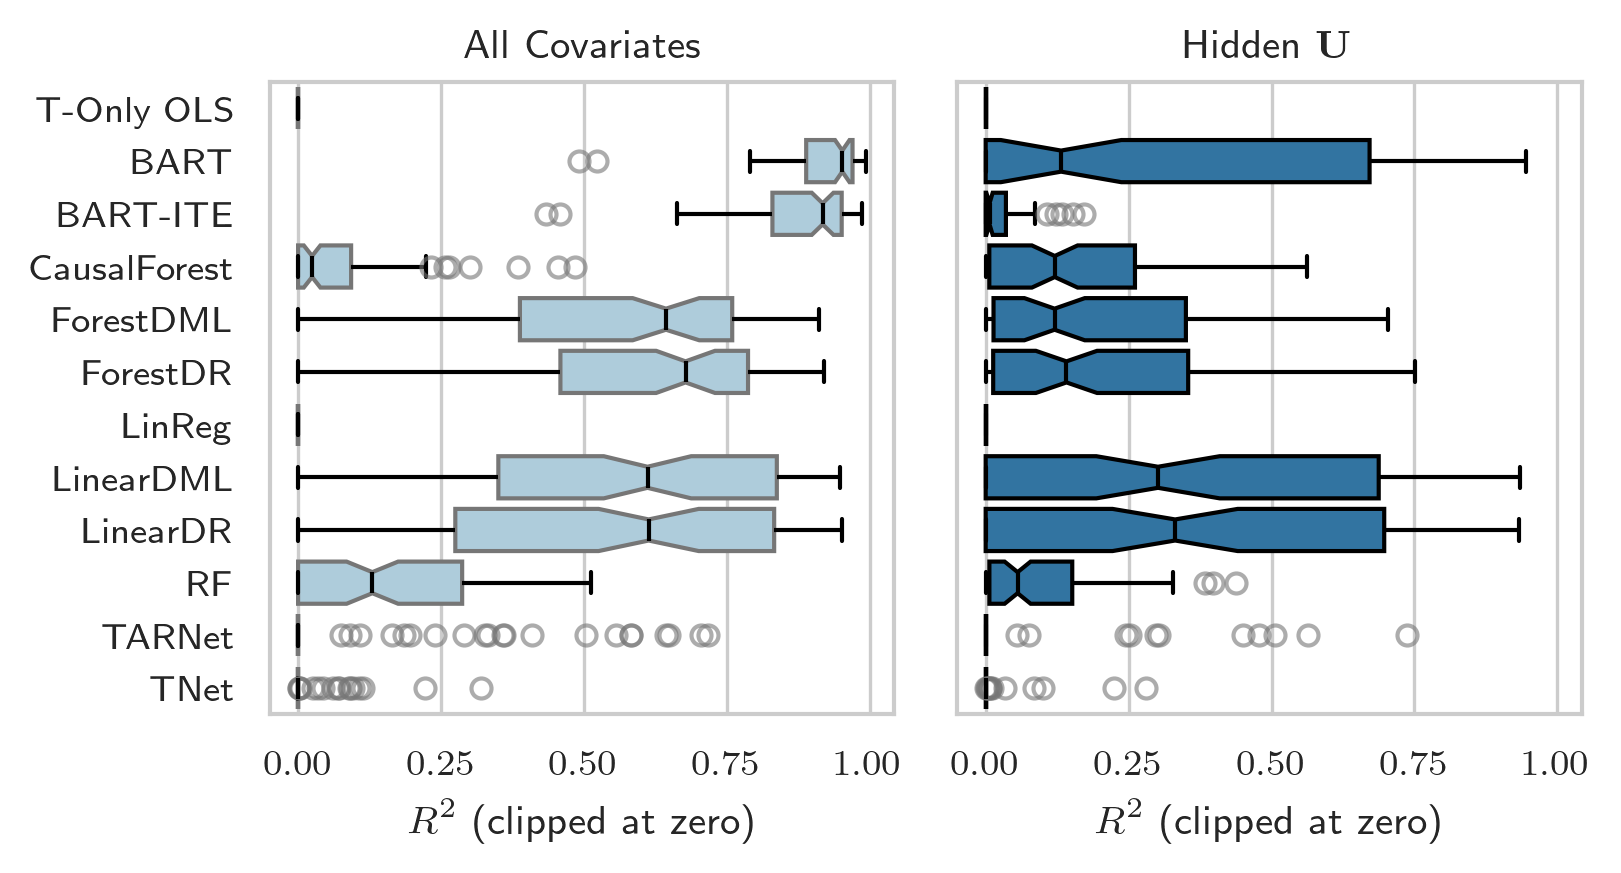

In [10]:
cate_10k_performance_df = format_cate_performance_df(estimation_df=estimation_10k_df)
cate_10k_performance_df['method_name'] = cate_10k_performance_df['method_name'].replace({
    'NaiveLinReg': 'T-Only OLS',
    'CausalForestDML': 'ForestDML',
    'SNet1': 'TARNet',
    'Conformal': 'CQR'
})

boxplot_settings = {
    'medianprops': {'color': 'black'},
    'whiskerprops': {'color': 'black'},
    'capprops': {'color': 'black'},
    'flierprops': {'alpha': 0.6},
    'palette': 'Paired',
    'meanprops': {'markerfacecolor': 'red', 'markeredgecolor': 'black', 'markersize': 5},
    'notch': True
}
showmeans = False
sns.set(rc={'text.usetex' : True}, font_scale=1, context='paper')
sns.set_style('whitegrid')

method_order = ['T-Only OLS', 'BART', 'BART-ITE', 'CausalForest', 'ForestDML', 'ForestDR', 'LinReg', 'LinearDML', 'LinearDR', 'RF', 'TARNet', 'TNet']
fig, axes = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(5.5, 3), dpi=300, sharex=True)
axes = axes.ravel()
sns.boxplot(
    data=cate_10k_performance_df.query("model_name=='llama-3-8b' & setting=='All Covariates'"), 
    y='method_name', 
    x='R2', 
    hue='setting',
    showmeans=showmeans,
    order=method_order,
    **boxplot_settings,
    ax=axes[0],
)
axes[0].set_title('All Covariates')
axes[0].legend().remove()
axes[0].set_ylabel('')
axes[0].set_xlabel(r'$R^2$ (clipped at zero)')

sns.boxplot(
    data=cate_10k_performance_df.query("model_name=='llama-3-8b' & setting=='Hidden $\mathbf{U}$'"), 
    y='method_name', 
    x='R2', 
    hue='setting',
    showmeans=showmeans,
    order=method_order,
    **boxplot_settings,
    ax=axes[1],
)
for patch in axes[1].patches:
    patch.set_facecolor('#3274A1')
    patch.set_edgecolor('black')
axes[1].legend().remove()
axes[1].set_title(r'Hidden $\mathbf{U}$')
axes[1].set_ylabel('')
axes[1].set_xlabel(r'$R^2$ (clipped at zero)')

axes[0].xaxis.grid(True)
axes[1].xaxis.grid(True)
plt.tight_layout()
plt.show()

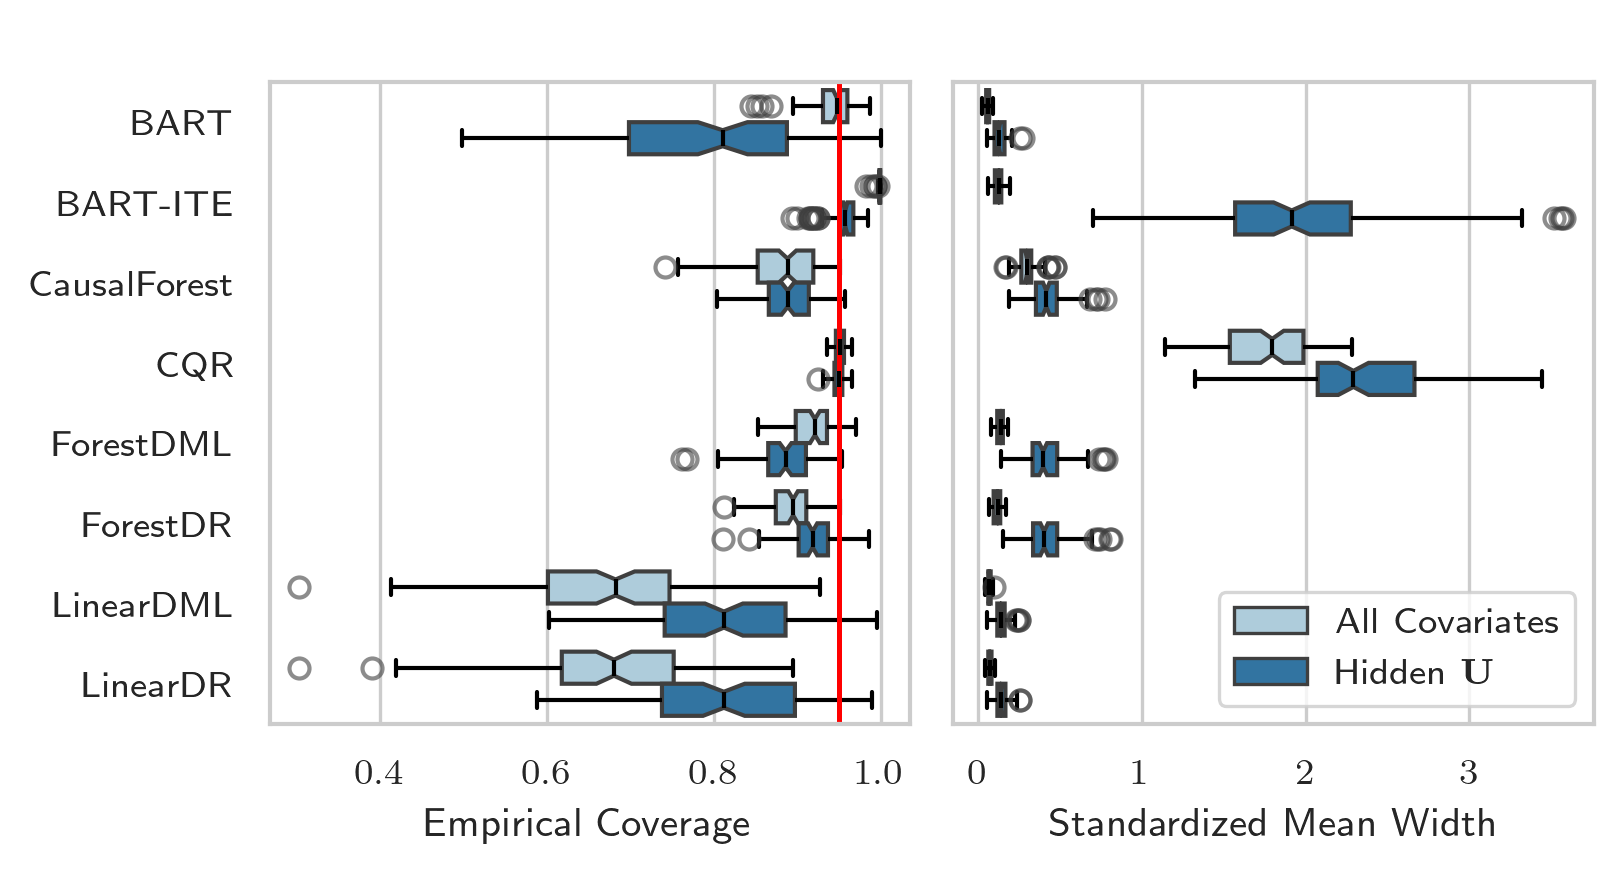

In [11]:
# intervals
method_order = ['BART', 'BART-ITE', 'CausalForest', 'CQR', 'ForestDML', 'ForestDR', 'LinearDML', 'LinearDR']
fig, axes = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(5.5, 3), dpi=300, sharex=False)
axes = axes.ravel()
subset_df = cate_10k_performance_df[cate_10k_performance_df['model_name'] == 'llama-3-8b'].dropna(subset=['coverage_cate'])
sns.boxplot(
    data=subset_df, 
    y='method_name', 
    x='coverage_cate', 
    hue='setting',
    ax=axes[0],
    order=method_order,
    **boxplot_settings
)
axes[0].set_ylabel('')
axes[0].axvline(x=0.95, color='red')
axes[0].legend().remove()
axes[0].set_xlabel('Empirical Coverage')

sns.boxplot(
    data=subset_df,
    y='method_name',
    x='sd_width_cate',
    hue='setting',
    ax=axes[1],
    order=method_order,
    **boxplot_settings
)
axes[1].legend(title='')
axes[1].set_xlabel('Standardized Mean Width')

axes[0].set_title(' ')
axes[0].xaxis.grid(True)
axes[1].xaxis.grid(True)
plt.tight_layout()
plt.show()

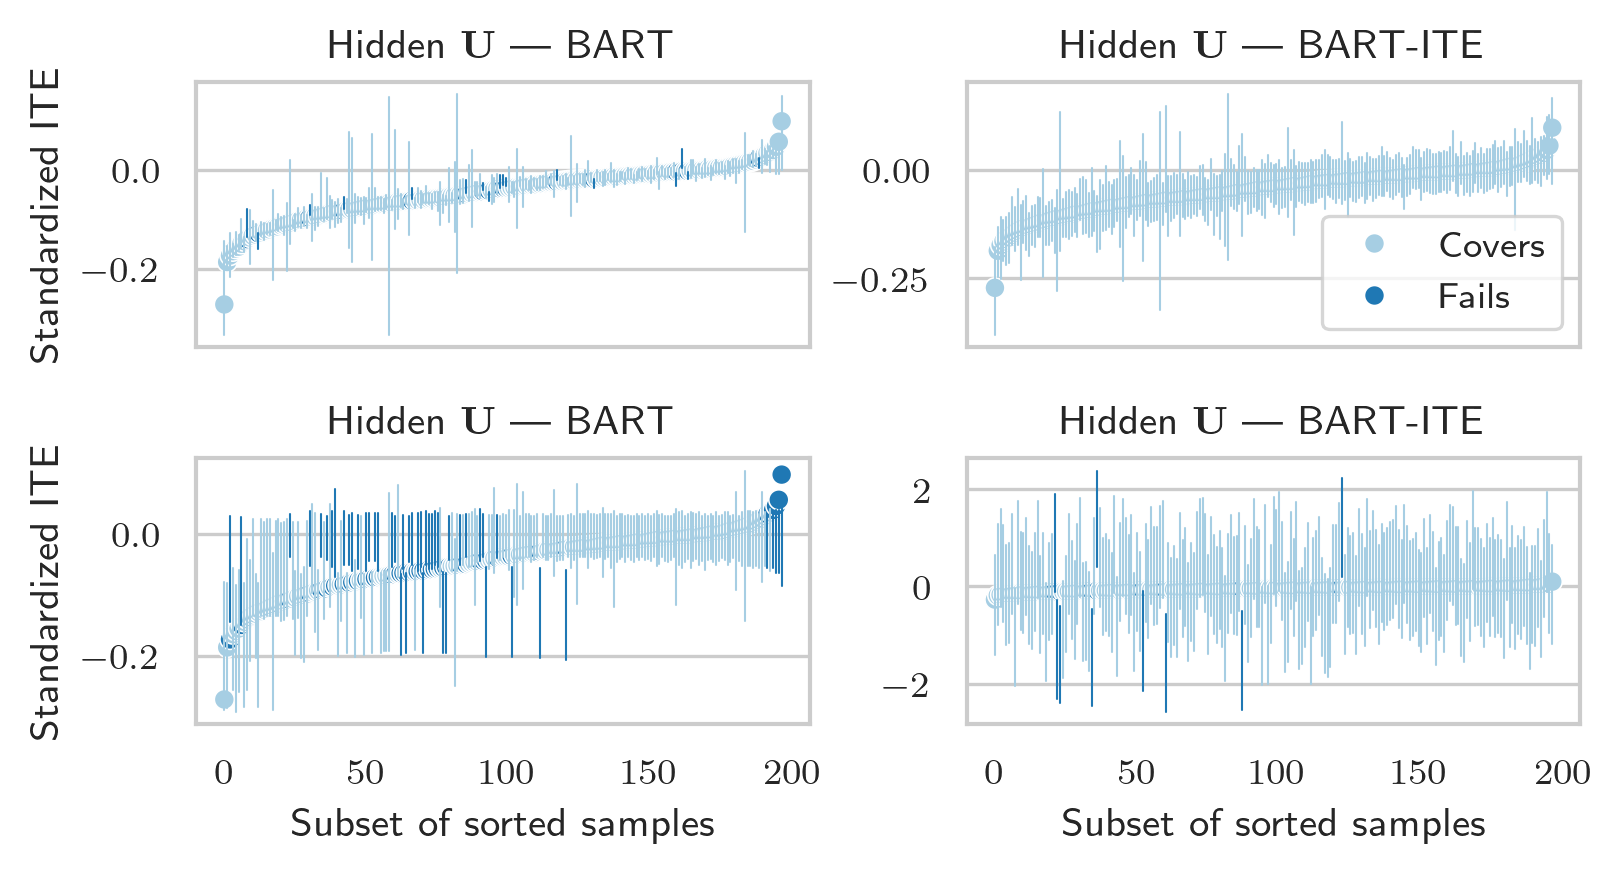

In [12]:
df_path = 'data/cancer_example/llama-3-8b/10k/llama-3-8b_bcancer_10k_11.csv'

interval_example = estimation_10k_df[estimation_10k_df['df_path'] == df_path]
confounding_setting = interval_example['covariate_names'].apply(len) < 12
all_covariates_setting = (1 - confounding_setting).astype(bool)

coverage_dfs = []
for setting_name, setting in [('All Covariates', all_covariates_setting), (r'Hidden $\mathbf{U}$', confounding_setting)]:
    for method_name in ['BART', 'BART-ITE']:
        sd_y = interval_example[setting]['y'].values[0].std()
        ites = interval_example[setting]['ite'].values[0] / sd_y
        lower = interval_example[setting][f'cate_lower_bounds_{method_name}'].values[0] / sd_y
        upper = interval_example[setting][f'cate_upper_bounds_{method_name}'].values[0] / sd_y
        covers = (ites > lower) * (ites < upper)
        df = pd.DataFrame(dict(ite=ites, lower=lower, upper=upper, covers=covers, method=method_name, setting=setting_name)).sort_values('ite')
        df['full_index'] = list(range(df.shape[0]))
        df['sample'] = df['full_index'] % 51 == 0
        df['index'] = np.nan
        df['index'][df['sample']] = list(range(sum(df['sample'])))
        coverage_dfs.append(df)
coverage_df = pd.concat(coverage_dfs, axis=0)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(5.5, 3), dpi=300, sharex=True, sharey=False)
axes = axes.ravel()
    
colors = sns.color_palette('Paired')
i = 0
for setting in ['All Covariates', r'Hidden $\mathbf{U}$']:
    for method in ['BART', 'BART-ITE']:
        query = f"setting=='{setting}' & sample==True & method=='{method}'"
        df = coverage_df.query(query)
        sns.scatterplot(data=df, x='index', y='ite', hue='covers', palette='Paired', ax=axes[i], hue_order=[True, False])
        for _, row in df.iterrows():
            color = colors[0] if row['covers'] else colors[1]
            axes[i].plot(
                [row['index'], row['index']], [row['lower'], row['upper']], 
                color=color, 
                lw=0.5
            )
        axes[i].set_title(f'{setting_name} | {method}')
        i += 1
handles, labels = axes[0].get_legend_handles_labels()
axes[1].legend(title='', handles=handles, labels=['Covers', 'Fails'])
for i in range(4):
    if i != 1:
        axes[i].legend().remove()
    axes[i].set_xlabel('Subset of sorted samples')
    if i % 2 == 0:
        axes[i].set_ylabel('Standardized ITE')
    else:
        axes[i].set_ylabel('')
    axes[i].xaxis.grid(False, which='major')
plt.tight_layout()
plt.show()
    